# Combo B (v9): Single-Node Action + 2-Layer GCN + Curriculum Learning + Potential-Based Reward Shaping

**Goal**: Optimize graph layouts using reinforcement learning (PPO) to minimize edge crossings on the Rome dataset (train: 1-9999, test: 10000-10100).

**v9 architectural fixes (vs. v7.5)**
1. **Action ↔ Observation coupling.** The environment now deterministically picks the target node (argmax of per-node crossings, tie-break to lowest index, fallback to highest-degree node when zero crossings), writes it into the observation as a one-hot mask `target_node_mask`, and applies the action to the same node. The GNN feature extractor replaces the v7.5 mean-pool with a target-node gather, so the policy head is conditioned on the embedding of the exact node that will be moved.
2. **Unified crossing computation.** All crossing counts (global, per-node observation feature, reward term) now go through a single helper built on `XingLoss.edges_intersect` with `eps = 1e-6`. The hand-written `_seg_intersect` routine has been removed.

**Pipeline at evaluation time**:
1. Load trained PPO policy from disk (`ppo_combo_b_v9.zip`).
2. For each test graph: initialize from `neato`, GD² pre-optimize (inside `env.reset()`), then roll out the PPO policy for up to 200 steps.
3. Optionally polish the PPO output with GD + Hill Climbing + SA (`multi_strategy_refinement`). Both the pure-PPO number and the PPO+refinement number are reported separately.
4. Compare against `neato`, `sfdp`, SA, and SmartGD (from `GraphDrawingBenchmark/metrics.csv`).

## 0. Setup & Configuration

In [1]:
import os
import sys
import time
import json
import random
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional, Type

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.7.0
Device: cpu


In [2]:
# ============================================================
# CONFIGURATION — Combo B: Single-Node + 2-Layer GCN + Curriculum
# ============================================================
# Override with environment variables so this runs on other machines:
#   export ROME_DIR=/path/to/rome
#   export BENCHMARK_DIR=/path/to/GraphDrawingBenchmark
ROME_DIR = os.environ.get(
    "ROME_DIR",
    "/Users/mao/Downloads/Project_RL/rome",
)
# Directory that contains metrics.csv and baseline_metrics/*.csv
# (cloned from https://github.com/yolandalalala/GraphDrawingBenchmark)
BENCHMARK_DIR = os.environ.get(
    "BENCHMARK_DIR",
    os.path.join(ROME_DIR, ".."),
)
SAVE_PATH = "ppo_combo_b_v9"
OUTPUT_DIR = "./results_combo_b_v9"

MAX_NODES = 100
MAX_EDGES = 200
TIMESTEPS_PHASE1 = 100000   # curriculum phase 1: small graphs
TIMESTEPS_PHASE2 = 200000   # curriculum phase 2: all graphs
N_STARTS = 10               # multi-start count for evaluation
SEED = 42                   # global reproducibility seed

# --- Global seeding (🟡-1 reproducibility) ---
# Applied here so every random draw downstream is deterministic across runs.
import random as _random
_random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Rome dir     : {ROME_DIR}")
print(f"Benchmark dir: {BENCHMARK_DIR}")
print(f"Graphs found : {len([f for f in os.listdir(ROME_DIR) if f.endswith('.graphml')])}")

Rome dir     : /Users/mao/Downloads/Project_RL/rome
Benchmark dir: /Users/mao/Downloads/Project_RL/rome/..
Graphs found : 11534


## 1. XingLoss — Edge Crossing Computation

In [3]:
class XingLoss:
    def __init__(self, G: nx.Graph, device=None, soft=False, sharpness=10.0):
        nodes = list(G.nodes())
        edges = [[nodes.index(i), nodes.index(j)] for i, j in G.edges]
        self.edges = torch.tensor(edges, dtype=torch.long)
        if device is None:
            device = torch.device("cpu")
        self.device = device
        self.soft = soft
        self.sharpness = sharpness

    @staticmethod
    def cross_2d(v, u):
        return v[..., 0] * u[..., 1] - v[..., 1] * u[..., 0]

    @staticmethod
    def dot_2d(v, u):
        return torch.sum(v * u, dim=-1)

    def edges_intersect(self, edge_1_start_pos, edge_1_end_pos,
                        edge_2_start_pos, edge_2_end_pos, eps=1e-6):
        p = edge_1_start_pos
        q = edge_2_start_pos
        r = edge_1_end_pos - p
        s = edge_2_end_pos - q
        p = p + eps * r
        q = q + eps * s
        r = r * (1 - 2 * eps)
        s = s * (1 - 2 * eps)
        qmp = q - p
        qmpxs = XingLoss.cross_2d(qmp, s)
        qmpxr = XingLoss.cross_2d(qmp, r)
        rxs = XingLoss.cross_2d(r, s)
        rdr = XingLoss.dot_2d(r, r)
        t0 = XingLoss.dot_2d(qmp, r) / (rdr + 1e-12)
        t1 = t0 + XingLoss.dot_2d(s, r) / (rdr + 1e-12)
        t = qmpxs / (rxs + 1e-12)
        u = qmpxr / (rxs + 1e-12)

        def sigmoid(x):
            return torch.sigmoid(x * self.sharpness)

        if self.soft:
            p5 = torch.tensor(0.5, device=rxs.device, dtype=rxs.dtype)
            M_peak = sigmoid(p5) * (1 - sigmoid(-p5))
            def inside_norm(t):
                M = sigmoid(t) * (1 - sigmoid(t - 1))
                return M / (M_peak + 1e-12)
            Mt = inside_norm(t)
            Mu = inside_norm(u)
            return Mt * Mu
        else:
            zero = torch.tensor(0.0, device=rxs.device, dtype=rxs.dtype)
            parallel = torch.isclose(rxs, zero)
            collinear = parallel & torch.isclose(qmpxr, zero)
            intersects_collinear = collinear & ((torch.max(t0, t1) > 0) & (torch.min(t0, t1) < 1))
            intersects_skew = ~parallel & (t > 0) & (t < 1) & (u > 0) & (u < 1)
            return intersects_collinear | intersects_skew

    def __call__(self, coords: torch.Tensor) -> torch.Tensor:
        num_edges = self.edges.shape[0]
        idx_i, idx_j = torch.triu_indices(num_edges, num_edges, offset=1)
        edge_i = self.edges[idx_i]
        edge_j = self.edges[idx_j]
        no_shared_nodes = ~(
            (edge_i[:, 0] == edge_j[:, 0]) | (edge_i[:, 0] == edge_j[:, 1]) |
            (edge_i[:, 1] == edge_j[:, 0]) | (edge_i[:, 1] == edge_j[:, 1])
        )
        edge_i = edge_i[no_shared_nodes]
        edge_j = edge_j[no_shared_nodes]
        if edge_i.shape[0] == 0:
            return torch.tensor(0.0, device=coords.device)
        edge_1_start_pos = coords[edge_i[:, 0], :2]
        edge_1_end_pos = coords[edge_i[:, 1], :2]
        edge_2_start_pos = coords[edge_j[:, 0], :2]
        edge_2_end_pos = coords[edge_j[:, 1], :2]
        crossings = self.edges_intersect(edge_1_start_pos, edge_1_end_pos,
                                         edge_2_start_pos, edge_2_end_pos)
        return crossings.sum().float()

print("XingLoss defined.")

XingLoss defined.


## 2. GNN Layers — Pure PyTorch (no torch_geometric needed)Custom GCN and multi-head GAT layers.

In [4]:
class GCNLayer(nn.Module):
    """Graph Convolutional Layer: H' = D^{-1/2} A D^{-1/2} H W + b"""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        self.bias = nn.Parameter(torch.zeros(out_dim))

    def forward(self, x, adj_norm):
        return adj_norm @ self.W(x) + self.bias


class GATLayer(nn.Module):
    """Graph Attention Layer (single-head)."""
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        self.attn_src = nn.Linear(out_dim, 1, bias=False)
        self.attn_dst = nn.Linear(out_dim, 1, bias=False)
        self.leaky_relu = nn.LeakyReLU(0.2)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, adj):
        h = self.W(x)
        attn_src = self.attn_src(h)
        attn_dst = self.attn_dst(h)
        attn = attn_src + attn_dst.T
        attn = attn.masked_fill(adj == 0, float('-inf'))
        attn = self.leaky_relu(attn)
        attn = F.softmax(attn, dim=-1)
        attn = torch.nan_to_num(attn, nan=0.0)
        attn = self.dropout(attn)
        return attn @ h


class MultiHeadGATLayer(nn.Module):
    """Multi-head GAT: concat K heads then project."""
    def __init__(self, in_dim, out_dim, num_heads=4, dropout=0.1):
        super().__init__()
        assert out_dim % num_heads == 0
        head_dim = out_dim // num_heads
        self.heads = nn.ModuleList([
            GATLayer(in_dim, head_dim, dropout) for _ in range(num_heads)
        ])
        self.proj = nn.Linear(out_dim, out_dim)

    def forward(self, x, adj):
        head_outputs = [head(x, adj) for head in self.heads]
        h = torch.cat(head_outputs, dim=-1)
        return self.proj(h)


class GNNEncoder(nn.Module):
    """3-layer GNN encoder with residual connections."""
    def __init__(self, in_dim=10, hidden_dim=64, num_layers=3, use_attention=True, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.input_proj = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
        )
        self.gnn_layers = nn.ModuleList()
        self.layer_norms = nn.ModuleList()
        for _ in range(num_layers):
            if use_attention:
                self.gnn_layers.append(MultiHeadGATLayer(hidden_dim, hidden_dim, num_heads=4, dropout=dropout))
            else:
                self.gnn_layers.append(GCNLayer(hidden_dim, hidden_dim))
            self.layer_norms.append(nn.LayerNorm(hidden_dim))

    def forward(self, x, adj):
        h = self.input_proj(x)
        for gnn, ln in zip(self.gnn_layers, self.layer_norms):
            h_new = gnn(h, adj)
            h_new = ln(h_new)
            h_new = F.relu(h_new)
            h = h + h_new  # residual
        return h

# Quick test
enc = GNNEncoder(in_dim=10, hidden_dim=64)
x_test = torch.randn(20, 10)
adj_test = torch.eye(20)
out_test = enc(x_test, adj_test)
print(f"GNN Encoder: {sum(p.numel() for p in enc.parameters()):,} params")
print(f"Input: {x_test.shape} → Output: {out_test.shape}")

GNN Encoder: 26,368 params
Input: torch.Size([20, 10]) → Output: torch.Size([20, 64])


## 3. Feature Extractor (2-Layer GCN)SB3-compatible feature extractor using 2-layer GCN (lightweight for curriculum learning).

In [5]:
class GNNFeatureExtractorSingleNode(BaseFeaturesExtractor):
    """2-layer GCN feature extractor for Combo B v9 (single-node actions).

    v9 architectural fix — action <-> observation coupling
    ------------------------------------------------------
    In v7.5 this extractor did a mean-pool over all node embeddings, so the
    policy head saw a single graph-level summary and could not learn
    node-specific behaviour. Combined with the random node selection in
    step(), the policy could only learn an average displacement that works
    in expectation.

    v9 replaces mean-pool with a TARGET-NODE GATHER:
      * The environment writes the node-to-be-moved (argmax of per-node
        crossings, computed by the unified XingLoss routine) into the
        observation as a one-hot mask ``target_node_mask``.
      * The feature extractor gathers the embedding of that specific node
        and concatenates it with the graph-mean embedding and the global
        features.

    Result: the action head is now conditioned on the embedding of the exact
    node that will receive the displacement, so the policy CAN learn
    node-specific behaviour.
    """

    def __init__(self, observation_space, max_nodes, max_edges, node_feat_dim=10,
                 global_feat_dim=5, hidden_dim=32, num_gnn_layers=2,
                 use_attention=False):
        super().__init__(observation_space, features_dim=hidden_dim)
        self.max_nodes = max_nodes
        self.max_edges = max_edges
        self.node_feat_dim = node_feat_dim
        self.global_feat_dim = global_feat_dim
        self.hidden_dim = hidden_dim

        # Input projections
        self.node_proj = nn.Linear(node_feat_dim, hidden_dim)
        self.global_proj = nn.Linear(global_feat_dim, hidden_dim)

        # GNN stack (2-layer by default)
        self.gnn_layers = nn.ModuleList()
        self.layer_norms = nn.ModuleList()
        for _ in range(num_gnn_layers):
            if use_attention:
                self.gnn_layers.append(MultiHeadGATLayer(hidden_dim, hidden_dim,
                                                         num_heads=4, dropout=0.1))
            else:
                self.gnn_layers.append(GCNLayer(hidden_dim, hidden_dim))
            self.layer_norms.append(nn.LayerNorm(hidden_dim))

        # v9: aggregate [target_node_embedding | graph_mean_embedding | global]
        # → features_dim = hidden_dim.
        self.agg = nn.Linear(hidden_dim * 3, hidden_dim)

    def forward(self, observations):
        node_feats   = observations["node_features"]      # (B, max_nodes, 10)
        global_feats = observations["global_features"]    # (B, 5)
        adj_matrix   = observations["adjacency_matrix"]   # (B, max_nodes, max_nodes)
        target_mask  = observations["target_node_mask"]   # (B, max_nodes) one-hot

        batch_size = node_feats.shape[0]
        device = node_feats.device

        # Project inputs
        node_h   = self.node_proj(node_feats)
        global_h = self.global_proj(global_feats)

        # GNN message passing with residual + layer norm
        for gnn, ln in zip(self.gnn_layers, self.layer_norms):
            if isinstance(gnn, GCNLayer):
                adj_with_loops = adj_matrix + torch.eye(self.max_nodes,
                                                        device=device).unsqueeze(0)
                degree = adj_with_loops.sum(dim=-1, keepdim=True).clamp(min=1e-8)
                adj_norm = adj_with_loops / degree
                node_h_new = torch.stack([gnn(node_h[i], adj_norm[i])
                                           for i in range(batch_size)])
            else:
                node_h_new = torch.stack([gnn(node_h[i], adj_matrix[i])
                                           for i in range(batch_size)])
            node_h_new = ln(node_h_new)
            node_h_new = F.relu(node_h_new)
            node_h = node_h + node_h_new  # residual

        # v9: gather the embedding of the target node (the one the env will
        # actually move). target_mask has exactly one 1.0 per batch row.
        target_h = (node_h * target_mask.unsqueeze(-1)).sum(dim=1)  # (B, H)

        # Keep a graph-level summary so the policy still sees overall shape.
        mean_h = node_h.mean(dim=1)  # (B, H)

        combined = torch.cat([target_h, mean_h, global_h], dim=-1)  # (B, 3H)
        output = self.agg(combined)                                  # (B, H)
        return output

print("GNNFeatureExtractorSingleNode defined (2-layer GCN, v9 target-node gather).")

GNNFeatureExtractorSingleNode defined (2-layer GCN, v9 target-node gather).


## 4. Environment — Single-Node Action + Potential-Based Reward ShapingEnvironment that moves a single node per step (random node selection in the current implementation; see step() docstring) and moves it, with potential-based shaped rewards.

### GD² Pre-optimization
Before PPO starts, we run 150 steps of gradient descent on soft crossing loss to optimize the neato layout. This gives PPO a much better starting point (similar to building on SmartGD/DeepGD results).

In [6]:
class GraphLayoutEnvSingleNode(gym.Env):
    """Single-node action environment for graph layout optimization (v9).

    v9 fixes (vs. v7.5)
    -------------------
    1. ACTION <-> OBSERVATION COUPLING.
       Previously ``step()`` hard-coded ``USE_MAX_CROSSING_NODE=False`` and
       picked the node uniformly at random, while the GNN mean-pooled node
       embeddings before the action head, so the policy could not learn
       node-specific behaviour. In v9, each observation deterministically
       identifies the node that will be moved next by writing a one-hot
       mask ``target_node_mask``. The feature extractor gathers the
       embedding of that node, and ``step()`` applies the action to that
       same node. Action and observation now refer to the same entity.

    2. UNIFIED CROSSING COMPUTATION.
       Previously the per-node crossings fed to the policy as an
       observation feature were computed by a hand-written strict
       cross-product test (``_seg_intersect``) with no tolerance, while
       the reward-side count used ``XingLoss.edges_intersect`` with
       ``eps=1e-6``. These could disagree by a small integer on
       near-collinear layouts. In v9, ALL crossing-count computations
       (global, per-node, reward) go through a single helper built on
       ``XingLoss.edges_intersect`` with the same ``eps``. The hand-rolled
       ``_seg_intersect`` is removed.

    Action: [dx, dy] applied to the deterministically-selected target node.
    Reward: base crossing reduction + potential-based shaping.
    """
    metadata = {'render_modes': []}

    def __init__(self, graph_paths, max_steps=200, max_nodes=MAX_NODES, max_edges=MAX_EDGES):
        super().__init__()
        self.graph_paths = graph_paths
        self.max_steps = max_steps
        self.max_nodes = max_nodes
        self.max_edges = max_edges

        # Action: [dx, dy] for the single target node
        self.action_space = spaces.Box(low=-1, high=1, shape=(2,), dtype=np.float32)

        # Observation: node features + global features + adjacency + target-node one-hot mask (v9)
        self.observation_space = spaces.Dict({
            "node_features":     spaces.Box(low=-np.inf, high=np.inf,
                                            shape=(max_nodes, 10), dtype=np.float32),
            "global_features":   spaces.Box(low=-np.inf, high=np.inf,
                                            shape=(5,), dtype=np.float32),
            "adjacency_matrix":  spaces.Box(low=0, high=1,
                                            shape=(max_nodes, max_nodes), dtype=np.float32),
            "target_node_mask":  spaces.Box(low=0, high=1,
                                            shape=(max_nodes,), dtype=np.float32),
        })

        self.G = None
        self.coords = None
        self.step_count = 0
        self.initial_crossings = None
        self.current_crossings = None
        self.best_crossings = None
        self.best_coords = None
        self.patience = 0
        self.adaptive_scale = 1.0
        self.xing_loss = None
        self.xing_loss_soft = None
        self.target_node_idx = 0      # v9: deterministically set in _get_obs()
        self.n_nodes = 0

    # -------------------- graph loading --------------------

    def _load_graph(self, path):
        G = nx.read_graphml(path)
        G = nx.convert_node_labels_to_integers(G, ordering="sorted")
        if not nx.is_connected(G):
            G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
            G = nx.convert_node_labels_to_integers(G, ordering="sorted")
        return G

    def _get_neato_layout(self, G):
        try:
            pos = nx.nx_agraph.graphviz_layout(G, prog="neato")
        except Exception:
            pos = nx.spring_layout(G, seed=42)
            pos = {k: (v[0]*100, v[1]*100) for k, v in pos.items()}
        return np.array([[pos[v][0], pos[v][1]] for v in G.nodes()], dtype=np.float32)

    def _compute_topo_features(self, G):
        """7 static topology features per node."""
        n = G.number_of_nodes()
        nodes = list(range(n))
        degrees = np.array([G.degree(v) for v in nodes], dtype=np.float32)
        max_deg = degrees.max()
        norm_deg = degrees / max_deg if max_deg > 0 else degrees

        cc = nx.clustering(G)
        clust = np.array([cc.get(v, 0.0) for v in nodes], dtype=np.float32)

        bc = nx.betweenness_centrality(G)
        between = np.array([bc.get(v, 0.0) for v in nodes], dtype=np.float32)

        try: pr = nx.pagerank(G, max_iter=100)
        except: pr = {v: 1.0/n for v in nodes}
        pagerank = np.array([pr.get(v, 0.0) for v in nodes], dtype=np.float32)
        pr_max = pagerank.max()
        if pr_max > 0: pagerank /= pr_max

        local_dens = np.zeros(n, dtype=np.float32)
        for v in nodes:
            neighbors = list(G.neighbors(v))
            k = len(neighbors)
            if k >= 2:
                subg = G.subgraph(neighbors)
                local_dens[v] = subg.number_of_edges() / (k*(k-1)/2)

        triangles = nx.triangles(G)
        tri = np.array([triangles.get(v, 0) for v in nodes], dtype=np.float32)
        tri_max = tri.max()
        if tri_max > 0: tri /= tri_max

        num_edges_norm = np.full(n, G.number_of_edges()/100.0, dtype=np.float32)
        return np.stack([norm_deg, clust, between, pagerank, local_dens, tri, num_edges_norm], axis=1)

    # -------------------- unified crossing helpers (v9) --------------------

    def _compute_crossings(self, coords):
        """Total edge crossings using XingLoss (unified)."""
        with torch.no_grad():
            return int(self.xing_loss(torch.tensor(coords, dtype=torch.float32)).item())

    def _compute_soft_crossings(self, coords):
        with torch.no_grad():
            return float(self.xing_loss_soft(torch.tensor(coords, dtype=torch.float32)).item())

    def _compute_per_node_crossings_xing(self, coords):
        """Per-node crossing counts via the SAME XingLoss.edges_intersect
        routine that the reward uses. Returns a raw int32 count per node
        (not normalized) plus the total crossing count.

        v9 FIX: this replaces the hand-written ``_seg_intersect``-based
        implementation from v7.5 so that observation and reward use a single
        crossing definition with a single tolerance (``eps = 1e-6``).
        """
        n = self.n_nodes
        per_node = np.zeros(n, dtype=np.int32)
        if n == 0 or self.G.number_of_edges() < 2:
            return per_node, 0

        edges_list = list(self.G.edges())
        nodes_ordered = list(self.G.nodes())
        node_index = {nd: idx for idx, nd in enumerate(nodes_ordered)}
        # (num_edges, 2) tensor of node indices
        edge_tensor = torch.tensor(
            [[node_index[u], node_index[v]] for u, v in edges_list],
            dtype=torch.long,
        )
        num_edges = edge_tensor.shape[0]
        idx_i, idx_j = torch.triu_indices(num_edges, num_edges, offset=1)
        edge_i = edge_tensor[idx_i]
        edge_j = edge_tensor[idx_j]
        # Drop pairs that share a node
        keep = ~(
            (edge_i[:, 0] == edge_j[:, 0]) | (edge_i[:, 0] == edge_j[:, 1]) |
            (edge_i[:, 1] == edge_j[:, 0]) | (edge_i[:, 1] == edge_j[:, 1])
        )
        edge_i = edge_i[keep]
        edge_j = edge_j[keep]
        if edge_i.shape[0] == 0:
            return per_node, 0

        coords_t = torch.tensor(coords, dtype=torch.float32)
        p1 = coords_t[edge_i[:, 0], :2]
        p2 = coords_t[edge_i[:, 1], :2]
        p3 = coords_t[edge_j[:, 0], :2]
        p4 = coords_t[edge_j[:, 1], :2]
        with torch.no_grad():
            # Reuse the SAME routine used by XingLoss for global/reward count.
            crossings_bool = self.xing_loss.edges_intersect(p1, p2, p3, p4).to(torch.bool)
        total = int(crossings_bool.sum().item())

        # Distribute each crossing to its 4 incident endpoints
        e_i_np = edge_i.numpy()
        e_j_np = edge_j.numpy()
        mask_np = crossings_bool.numpy()
        crossed_i = e_i_np[mask_np]
        crossed_j = e_j_np[mask_np]
        for row_i, row_j in zip(crossed_i, crossed_j):
            per_node[row_i[0]] += 1
            per_node[row_i[1]] += 1
            per_node[row_j[0]] += 1
            per_node[row_j[1]] += 1
        return per_node, total

    def _select_target_node(self, per_node_raw):
        """Deterministic target-node rule (v9): pick the node with the
        highest per-node crossing count. Ties are broken by lowest index,
        which keeps the rule reproducible. If no edges cross (per_node is
        all zero), fall back to the highest-degree node.
        """
        if per_node_raw is None or per_node_raw.size == 0:
            return 0
        if per_node_raw.max() > 0:
            return int(np.argmax(per_node_raw))
        # Fallback when the current layout has zero crossings: pick the
        # highest-degree node (still deterministic, still node-specific).
        degs = np.array(
            [self.G.degree(v) for v in list(self.G.nodes())],
            dtype=np.int32,
        )
        return int(np.argmax(degs)) if degs.size > 0 else 0

    # -------------------- reset / observation / step --------------------

    def reset(self, seed=None):
        super().reset(seed=seed)

        # Load a random graph (same preprocessing as evaluation)
        fpath = self.np_random.choice(self.graph_paths)
        self.G = nx.read_graphml(fpath)
        self.G = nx.convert_node_labels_to_integers(self.G, ordering="sorted")
        if not nx.is_connected(self.G):
            self.G = self.G.subgraph(
                max(nx.connected_components(self.G), key=len)
            ).copy()
            self.G = nx.convert_node_labels_to_integers(self.G, ordering="sorted")
        self.n_nodes = self.G.number_of_nodes()

        # Initialize coordinates (neato — teacher-recommended)
        try:
            pos = nx.nx_agraph.graphviz_layout(self.G, prog="neato")
            coords_dict = {node: pos[node] for node in self.G.nodes()}
        except Exception:
            coords_dict = nx.spring_layout(self.G, seed=42)
        nodes_ordered = list(self.G.nodes())
        self.coords = np.array([coords_dict[n] for n in nodes_ordered], dtype=np.float32)
        self.coords = self._normalize_coords(self.coords)

        # XingLoss instances (hard and soft) — used by ALL crossing computations.
        self.xing_loss = XingLoss(self.G, soft=False)
        self.xing_loss_soft = XingLoss(self.G, soft=True, sharpness=15.0)

        # Initial crossings
        self.initial_crossings = self._compute_crossings(self.coords)
        self.current_crossings = self.initial_crossings
        self.best_crossings = self.initial_crossings
        self.best_coords = self.coords.copy()

        # GD^2 pre-optimization (unchanged)
        if self.initial_crossings > 0:
            coords_t = torch.tensor(self.coords, dtype=torch.float32, requires_grad=True)
            gd_optimizer = torch.optim.Adam([coords_t], lr=0.05)
            for _gd_step in range(150):
                loss = self.xing_loss_soft(coords_t)
                gd_optimizer.zero_grad()
                loss.backward()
                gd_optimizer.step()
            self.coords = self._normalize_coords(coords_t.detach().numpy())
            self.initial_crossings = self._compute_crossings(self.coords)
            self.current_crossings = self.initial_crossings
            self.best_crossings = self.initial_crossings
            self.best_coords = self.coords.copy()

        self.step_count = 0
        self.patience = 0
        self.adaptive_scale = 1.0
        self.target_node_idx = 0   # will be overwritten inside _get_obs()

        return self._get_obs(), {}

    def _normalize_coords(self, coords):
        c_min = coords.min(axis=0)
        c_max = coords.max(axis=0)
        return (coords - c_min) / (c_max - c_min + 1e-8)

    def _get_obs(self):
        """Build observation dict and set the target node for the NEXT step.

        v9: per-node crossings are computed via the unified XingLoss
        routine (same tolerance as the reward), and the target node is
        written into the observation as a one-hot mask.
        """
        n_nodes = self.G.number_of_nodes()

        # Unified per-node crossings (same routine as reward)
        per_node_raw, _total = self._compute_per_node_crossings_xing(self.coords)
        per_node_feat = per_node_raw.astype(np.float32)
        mx = per_node_feat.max() if per_node_feat.size > 0 else 0.0
        if mx > 0:
            per_node_feat = per_node_feat / mx

        # Deterministic target-node selection (v9)
        self.target_node_idx = self._select_target_node(per_node_raw)

        # Node features (padded to max_nodes)
        node_feats = np.zeros((self.max_nodes, 10), dtype=np.float32)
        nodes_ordered = list(self.G.nodes())
        mean_coord = self.coords.mean(axis=0) if n_nodes > 1 else self.coords[0]
        for i in range(n_nodes):
            x, y = self.coords[i]
            degree = self.G.degree(nodes_ordered[i])
            crossing_count = per_node_feat[i]
            node_feats[i] = np.array([
                x, y,
                x * x, y * y,
                degree / max(n_nodes, 1),
                crossing_count,
                float(np.linalg.norm(self.coords[i] - mean_coord)) if n_nodes > 1 else 0.0,
                0.0, 0.0, 0.0,
            ], dtype=np.float32)

        # Global features
        density = 2 * self.G.number_of_edges() / (n_nodes * (n_nodes - 1)) if n_nodes > 1 else 0.0
        global_feats = np.array([
            self.current_crossings / max(self.initial_crossings, 1),
            density,
            n_nodes / self.max_nodes,
            self.best_crossings / max(self.initial_crossings, 1),
            self.step_count / self.max_steps,
        ], dtype=np.float32)

        # Adjacency (padded)
        adj = np.zeros((self.max_nodes, self.max_nodes), dtype=np.float32)
        node_index = {nd: idx for idx, nd in enumerate(nodes_ordered)}
        for u, v in self.G.edges():
            i, j = node_index[u], node_index[v]
            adj[i, j] = 1.0
            adj[j, i] = 1.0

        # v9: one-hot mask telling the policy WHICH node the action will affect
        target_mask = np.zeros((self.max_nodes,), dtype=np.float32)
        if 0 <= self.target_node_idx < self.max_nodes:
            target_mask[self.target_node_idx] = 1.0

        return {
            "node_features":    node_feats,
            "global_features":  global_feats,
            "adjacency_matrix": adj,
            "target_node_mask": target_mask,
        }

    def step(self, action):
        """Apply [dx, dy] to the target node chosen during the previous
        ``_get_obs()`` call. Since target_node_idx is part of the observation
        the policy saw, the action is tightly coupled to the observation.
        """
        self.step_count += 1
        n_nodes = self.G.number_of_nodes()

        selected_node_idx = int(np.clip(self.target_node_idx, 0, max(n_nodes - 1, 0)))

        # Apply displacement
        delta = np.array(action, dtype=np.float32) * 0.05 * self.adaptive_scale
        self.coords[selected_node_idx] = np.clip(
            self.coords[selected_node_idx] + delta, 0.0, 1.0
        )

        # Unified crossing count (same routine as per-node / reward)
        new_crossings = self._compute_crossings(self.coords)

        # Potential-based reward shaping (unchanged)
        phi_old = -self.current_crossings / max(self.initial_crossings, 1)
        phi_new = -new_crossings / max(self.initial_crossings, 1)
        potential_reward = 0.99 * phi_new - phi_old  # matches PPO gamma

        # Base reward
        crossing_reduction = self.current_crossings - new_crossings
        hard_reward = crossing_reduction * 0.5
        soft_reward = -new_crossings / max(self.initial_crossings, 1) * 0.1
        base_reward = hard_reward + soft_reward

        reward = base_reward + potential_reward * 5.0

        # Track best
        if new_crossings < self.best_crossings:
            self.best_crossings = new_crossings
            self.best_coords = self.coords.copy()
            self.patience = 0
        else:
            self.patience += 1

        # Adaptive scaling
        if self.patience > 10:
            self.adaptive_scale *= 0.99

        self.current_crossings = new_crossings

        terminated = self.step_count >= self.max_steps or self.best_crossings == 0

        info = {
            "best_crossings":     self.best_crossings,
            "current_crossings":  new_crossings,
            "improvement":        max(0, crossing_reduction),
            "target_node_idx":    selected_node_idx,
        }

        # Note: the NEXT target node is chosen inside _get_obs() below, based
        # on the post-step per-node crossing counts.
        return self._get_obs(), reward, terminated, False, info

print("GraphLayoutEnvSingleNode defined (v9: action↔obs coupled, unified crossing).")

GraphLayoutEnvSingleNode defined (v9: action↔obs coupled, unified crossing).


## 5. Local Search — Post-Processing RefinementGradient descent, hill climbing, and simulated annealing for final optimization.

In [7]:
def gradient_descent_refinement(G, coords, n_iters=200, lr=0.05, sharpness=15.0, verbose=False):
    coords_t = torch.tensor(coords, dtype=torch.float32, requires_grad=True)
    xing_soft = XingLoss(G, soft=True, sharpness=sharpness)
    xing_hard = XingLoss(G, soft=False)
    optimizer = optim.Adam([coords_t], lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_iters)
    best_crossings = int(xing_hard(coords_t.detach()).item())
    best_coords = coords_t.detach().clone()
    for i in range(n_iters):
        optimizer.zero_grad()
        loss = xing_soft(coords_t)
        loss.backward()
        optimizer.step(); scheduler.step()
        with torch.no_grad():
            hc = int(xing_hard(coords_t).item())
            if hc < best_crossings:
                best_crossings = hc; best_coords = coords_t.clone()
                if verbose and i % 20 == 0: print(f"  GD iter {i}: {hc}")
            if best_crossings == 0: break
    return best_coords.detach().numpy(), best_crossings


def hill_climbing_refinement(G, coords, n_iters=500, step_size=0.3, decay=0.995, verbose=False):
    xing = XingLoss(G, soft=False)
    n_nodes = coords.shape[0]
    current_coords = coords.copy()
    current_crossings = int(xing(torch.tensor(current_coords)).item())
    best_crossings = current_crossings; best_coords = current_coords.copy()
    for i in range(n_iters):
        node = np.random.randint(n_nodes)
        delta = np.random.randn(2).astype(np.float32) * step_size
        new_coords = current_coords.copy(); new_coords[node] += delta
        nc = int(xing(torch.tensor(new_coords)).item())
        if nc <= current_crossings:
            current_coords = new_coords; current_crossings = nc
            if nc < best_crossings:
                best_crossings = nc; best_coords = current_coords.copy()
                if verbose and i % 50 == 0: print(f"  HC iter {i}: {nc}")
        step_size *= decay
        if best_crossings == 0: break
    return best_coords, best_crossings


def simulated_annealing_refinement(G, coords, n_iters=2000, T_start=5.0, T_end=0.01,
                                    step_size=0.5, verbose=False):
    xing = XingLoss(G, soft=False)
    n_nodes = coords.shape[0]
    current_coords = coords.copy()
    current_crossings = int(xing(torch.tensor(current_coords)).item())
    best_crossings = current_crossings; best_coords = current_coords.copy()
    for i in range(n_iters):
        T = T_start * (T_end / T_start) ** (i / n_iters)
        cs = step_size * (T / T_start)
        node = np.random.randint(n_nodes)
        new_coords = current_coords.copy()
        new_coords[node] += np.random.randn(2).astype(np.float32) * cs
        nc = int(xing(torch.tensor(new_coords)).item())
        dc = nc - current_crossings
        if dc <= 0 or np.random.random() < np.exp(-dc / max(T, 1e-10)):
            current_coords = new_coords; current_crossings = nc
            if nc < best_crossings:
                best_crossings = nc; best_coords = current_coords.copy()
                if verbose and i % 100 == 0: print(f"  SA iter {i}: {nc}, T={T:.3f}")
        if best_crossings == 0: break
    return best_coords, best_crossings


def multi_strategy_refinement(G, coords, verbose=False):
    """Pipeline: GD → Hill Climbing → Simulated Annealing → Final GD polish."""
    xing = XingLoss(G, soft=False)
    initial = int(xing(torch.tensor(coords)).item())
    if initial == 0: return coords, 0
    best_coords = coords.copy(); best = initial
    if verbose: print(f"Refinement start: {initial} crossings")

    c, x = gradient_descent_refinement(G, best_coords, n_iters=150, lr=0.05, verbose=verbose)
    if x < best: best_coords, best = c, x
    if best > 0:
        c, x = hill_climbing_refinement(G, best_coords, n_iters=500, verbose=verbose)
        if x < best: best_coords, best = c, x
    if best > 0:
        c, x = simulated_annealing_refinement(G, best_coords, n_iters=1500, verbose=verbose)
        if x < best: best_coords, best = c, x
    if best > 0:
        c, x = gradient_descent_refinement(G, best_coords, n_iters=100, lr=0.02, sharpness=20.0, verbose=verbose)
        if x < best: best_coords, best = c, x

    if verbose: print(f"Refinement done: {initial} → {best} ({initial-best} reduced)")
    return best_coords, best

print("Local search functions defined.")

Local search functions defined.


## 6. Helper Functions

In [8]:
def get_graph_paths(rome_dir, min_idx=1, max_idx=9999, max_nodes=MAX_NODES):
    paths = []
    for fname in sorted(os.listdir(rome_dir)):
        if not fname.endswith(".graphml"): continue
        try: num = int(fname.split("grafo")[1].split(".")[0])
        except: continue
        if num < min_idx or num > max_idx: continue
        fpath = os.path.join(rome_dir, fname)
        G = nx.read_graphml(fpath)
        if G.number_of_nodes() <= max_nodes:
            paths.append(fpath)
    return paths


def compute_spc(results):
    """SPC = 100% * mean[(Di - Gi) / max(Di, Gi)]"""
    vals = []
    for r in results:
        Di, Gi = r["best_crossings"], r["neato_crossings"]
        denom = max(Di, Gi)
        vals.append((Di - Gi) / denom if denom > 0 else 0.0)
    return 100.0 * np.mean(vals)


class TrainingCallback(BaseCallback):
    def __init__(self, eval_freq=5000, verbose=1):
        super().__init__(verbose)
        self.eval_freq = eval_freq
        self.history = []
    def _on_step(self):
        if self.n_calls % self.eval_freq == 0:
            infos = self.locals.get("infos", [])
            if infos:
                imps = [i.get("improvement", 0) for i in infos if "improvement" in i]
                crosses = [i.get("best_crossings", 0) for i in infos if "best_crossings" in i]
                if imps:
                    self.history.append({"step": self.n_calls, "avg_imp": float(np.mean(imps)),
                                         "avg_cross": float(np.mean(crosses))})
                    if self.verbose:
                        print(f"  [Step {self.n_calls}] avg_imp={np.mean(imps):.1f} avg_cross={np.mean(crosses):.1f}")
        return True

print("Helpers defined.")

Helpers defined.


---## 7. Environment ValidationQuick check that the environment works.

In [9]:
# Load graph paths
train_paths = get_graph_paths(ROME_DIR, min_idx=1, max_idx=9999)
print(f"Training graphs: {len(train_paths)}")

# Create and test environment
test_env = GraphLayoutEnvSingleNode(train_paths, max_steps=200)
obs, info = test_env.reset()
print(f"Initial observation keys: {obs.keys()}")
print(f"Node features shape: {obs['node_features'].shape}")
print(f"Global features shape: {obs['global_features'].shape}")
print(f"Adjacency shape: {obs['adjacency_matrix'].shape}")

# Test a few steps
for _ in range(3):
    action = test_env.action_space.sample()
    obs, reward, terminated, truncated, info = test_env.step(action)
    print(f"Step: reward={reward:.3f}, best_cross={info['best_crossings']}, terminated={terminated}")

print("Environment validation passed!")


Training graphs: 9872
Initial observation keys: dict_keys(['node_features', 'global_features', 'adjacency_matrix', 'target_node_mask'])
Node features shape: (100, 10)
Global features shape: (5,)
Adjacency shape: (100, 100)
Step: reward=-0.050, best_cross=1, terminated=False
Step: reward=-0.050, best_cross=1, terminated=False
Step: reward=-0.050, best_cross=1, terminated=False
Environment validation passed!


---## 8. Training Phase 1: Curriculum (Small Graphs ≤30 nodes)

In [10]:
# Filter small graphs for curriculum phase 1
small_paths = [p for p in train_paths if nx.read_graphml(p).number_of_nodes() <= 30]
print(f"Small graphs (≤30 nodes): {len(small_paths)}")

# Create environment
env_phase1 = GraphLayoutEnvSingleNode(small_paths, max_steps=200)

# Define policy
policy_kwargs = {
    "features_extractor_class": GNNFeatureExtractorSingleNode,
    "features_extractor_kwargs": {
        "max_nodes": MAX_NODES,
        "max_edges": MAX_EDGES,
        "node_feat_dim": 10,
        "global_feat_dim": 5,
        "hidden_dim": 32,
        "num_gnn_layers": 2,
        "use_attention": False,
    },
    "net_arch": dict(pi=[128, 64], vf=[128, 64]),
    "activation_fn": torch.nn.ReLU,
}

# Create PPO model — use MultiInputPolicy for Dict observation space
model = PPO(
    "MultiInputPolicy",
    env_phase1,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=128,
    n_epochs=4,
    gamma=0.99,          # 🟡-8: matches shaping gamma for policy invariance
    seed=SEED,           # 🟡-1: deterministic PPO sampling
    policy_kwargs=policy_kwargs,
    device="cuda" if torch.cuda.is_available() else "cpu",
    verbose=1,
)

# Train phase 1
callback1 = TrainingCallback(eval_freq=5000, verbose=1)
print("Training Phase 1: small graphs...")
model.learn(total_timesteps=TIMESTEPS_PHASE1, callback=callback1)
phase1_history = callback1.history
print(f"Phase 1 complete! History: {len(phase1_history)} checkpoints")

Small graphs (≤30 nodes): 2305
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Training Phase 1: small graphs...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 100      |
|    ep_rew_mean     | -7.75    |
| time/              |          |
|    fps             | 430      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 1024     |
---------------------------------
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 72.1      |
|    ep_rew_mean          | -5.77     |
| time/                   |           |
|    fps                  | 197       |
|    iterations           | 2         |
|    time_elapsed         | 10        |
|    total_timesteps      | 2048      |
| train/                  |           |
|    approx_kl            | 0.0096543 |
|    clip_fraction        | 0.0466    |
|    clip_range      

---## 9. Training Phase 2: All Graphs (Fine-tuning)

In [11]:
# Switch to all graphs for phase 2
env_phase2 = GraphLayoutEnvSingleNode(train_paths, max_steps=200)
model.set_env(env_phase2)

# Lower learning rate for fine-tuning. Note: in stable-baselines3,
# PPO uses `model.lr_schedule` (a callable) internally. Assigning to
# `model.learning_rate` alone does NOT update the optimizer. We update both.
model.learning_rate = 5e-5
model.lr_schedule = lambda progress_remaining: 5e-5
for g in model.policy.optimizer.param_groups:
    g["lr"] = 5e-5

# Train phase 2
callback2 = TrainingCallback(eval_freq=5000, verbose=1)
print("Training Phase 2: all graphs, lower learning rate...")
model.learn(total_timesteps=TIMESTEPS_PHASE2, callback=callback2, reset_num_timesteps=False)
phase2_history = callback2.history

# Save model
model.save(SAVE_PATH)
print(f"Model saved to {SAVE_PATH}.zip")

# Combined history for plots
combined_history = phase1_history + phase2_history


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Training Phase 2: all graphs, lower learning rate...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 91       |
|    ep_rew_mean     | -13.9    |
| time/              |          |
|    fps             | 273      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 101376   |
---------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 97            |
|    ep_rew_mean          | -14.5         |
| time/                   |               |
|    fps                  | 165           |
|    iterations           | 2             |
|    time_elapsed         | 12            |
|    total_timesteps      | 102400        |
| train/                  |               |
|    approx_kl            | 0.00032320386 |
|    clip_fraction        | 0             |
| 

---## 10. Evaluation on Test Set

In [12]:
# ════════════════════════════════════════════════════════════════════════
# EVALUATION on test set (graphs 10000-10100) —  uses the
# trained PPO model. We report three numbers per graph:
#   - neato_crossings   : the baseline starting point
#   - ppo_crossings     : best crossings reached by the trained PPO policy
#                         rolling out on that graph (pure-RL number)
#   - refined_crossings : PPO result, then polished by multi_strategy_refinement
#                         (GD² + Hill Climb + SA). This is what we submit.
# ════════════════════════════════════════════════════════════════════════
import sys
from stable_baselines3 import PPO

print("=" * 70, flush=True)
print("Loading trained PPO policy from disk...", flush=True)
print("=" * 70, flush=True)
trained_model = PPO.load(SAVE_PATH)
print(f"Loaded PPO model: {SAVE_PATH}.zip", flush=True)


def ppo_rollout(graph_path, model, max_steps=200):
    """Run the trained PPO policy on a single graph; return (best_coords, best_xings).

    The env's reset() already runs GD² pre-optimization (same as training),
    so the "starting state" the PPO sees is the pre-optimized neato layout.
    The policy then takes max_steps actions trying to further improve.
    """
    env = GraphLayoutEnvSingleNode([graph_path], max_steps=max_steps)
    obs, _ = env.reset()
    for _ in range(max_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        if terminated or truncated:
            break
    return env.best_coords.copy(), int(env.best_crossings)


test_paths = get_graph_paths(ROME_DIR, min_idx=10000, max_idx=10100, max_nodes=MAX_NODES)  # 🟡-2: same filter as Cell 28
print(f"Test graphs found: {len(test_paths)}", flush=True)

results = []
t0 = time.time()
for test_idx, test_path in enumerate(test_paths):
    t_graph = time.time()
    G_raw = nx.read_graphml(test_path)
    G = nx.convert_node_labels_to_integers(G_raw, ordering="sorted")
    if not nx.is_connected(G):
        G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
        G = nx.convert_node_labels_to_integers(G, ordering="sorted")
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()

    if n_nodes > MAX_NODES:
        print(f"  Test {test_idx}: SKIP ({n_nodes} nodes > {MAX_NODES})", flush=True)
        continue

    # --- neato baseline (our own pipeline, used as Gi for our method) -----
    xing_hard = XingLoss(G, soft=False)
    try:
        neato_pos = nx.nx_agraph.graphviz_layout(G, prog="neato")
    except Exception:
        neato_pos = nx.spring_layout(G, seed=42)
    neato_coords = np.array([[neato_pos[v][0], neato_pos[v][1]] for v in G.nodes()],
                            dtype=np.float32)
    neato_coords = (neato_coords - neato_coords.min(axis=0)) / (
        neato_coords.max(axis=0) - neato_coords.min(axis=0) + 1e-8)
    neato_xings = int(xing_hard(torch.tensor(neato_coords)).item())

    # --- PPO rollout (pure-RL number) ------------------------------------
    ppo_coords, ppo_xings = ppo_rollout(test_path, trained_model, max_steps=200)

    # --- Optional refinement on top of PPO output (final submission) -----
    refined_coords, refined_xings = ppo_coords.copy(), ppo_xings
    if ppo_xings > 0:
        r_coords, r_x = multi_strategy_refinement(G, ppo_coords, verbose=False)
        if r_x < refined_xings:
            refined_coords, refined_xings = r_coords, r_x

    results.append({
        "graph_idx": test_idx,
        "n_nodes": n_nodes,
        "n_edges": n_edges,
        "neato_crossings": neato_xings,
        "ppo_crossings": ppo_xings,
        "best_crossings": refined_xings,  # submission = PPO + refinement
    })
    elapsed = time.time() - t_graph
    print(f"  Test {test_idx}: {n_nodes}n {n_edges}e → "
          f"neato={neato_xings}, ppo={ppo_xings}, refined={refined_xings}  ({elapsed:.1f}s)",
          flush=True)

total_time = time.time() - t0


def compute_spc_from_results(results, method_key):
    vals = []
    for r in results:
        Di, Gi = r[method_key], r["neato_crossings"]
        denom = max(Di, Gi)
        vals.append((Di - Gi) / denom if denom > 0 else 0.0)
    return 100.0 * np.mean(vals)


spc_ppo     = compute_spc_from_results(results, "ppo_crossings")
spc_refined = compute_spc_from_results(results, "best_crossings")
wins_ppo     = sum(1 for r in results if r["ppo_crossings"]  < r["neato_crossings"])
wins_refined = sum(1 for r in results if r["best_crossings"] < r["neato_crossings"])
print(f"\n{'='*70}", flush=True)
print(f"SPC (PPO only)      = {spc_ppo:.2f}%    wins: {wins_ppo}/{len(results)}", flush=True)
print(f"SPC (PPO + refine)  = {spc_refined:.2f}%    wins: {wins_refined}/{len(results)}", flush=True)
print(f"Total time: {total_time:.0f}s ({total_time/60:.1f} min)", flush=True)
print(f"{'='*70}", flush=True)


Loading trained PPO policy from disk...
Loaded PPO model: ppo_combo_b_v9.zip
Test graphs found: 99
  Test 0: 38n 52e → neato=11, ppo=8, refined=7  (1.0s)
  Test 1: 32n 32e → neato=0, ppo=0, refined=0  (0.2s)
  Test 2: 40n 45e → neato=4, ppo=3, refined=3  (1.0s)
  Test 3: 40n 50e → neato=13, ppo=5, refined=5  (1.0s)
  Test 4: 32n 37e → neato=4, ppo=3, refined=3  (0.9s)
  Test 5: 39n 49e → neato=23, ppo=11, refined=11  (1.0s)
  Test 6: 98n 136e → neato=125, ppo=74, refined=61  (3.7s)
  Test 7: 31n 34e → neato=2, ppo=1, refined=1  (0.8s)
  Test 8: 42n 61e → neato=39, ppo=18, refined=13  (1.9s)
  Test 9: 31n 37e → neato=2, ppo=2, refined=2  (0.9s)
  Test 10: 39n 50e → neato=12, ppo=8, refined=6  (1.0s)
  Test 11: 31n 36e → neato=1, ppo=1, refined=1  (0.9s)
  Test 12: 40n 53e → neato=13, ppo=8, refined=7  (1.1s)
  Test 13: 31n 36e → neato=1, ppo=1, refined=1  (0.9s)
  Test 14: 39n 52e → neato=16, ppo=8, refined=8  (1.0s)
  Test 15: 39n 45e → neato=3, ppo=3, refined=1  (0.9s)
  Test 16: 39n 

---## 11. Training Curve Plots

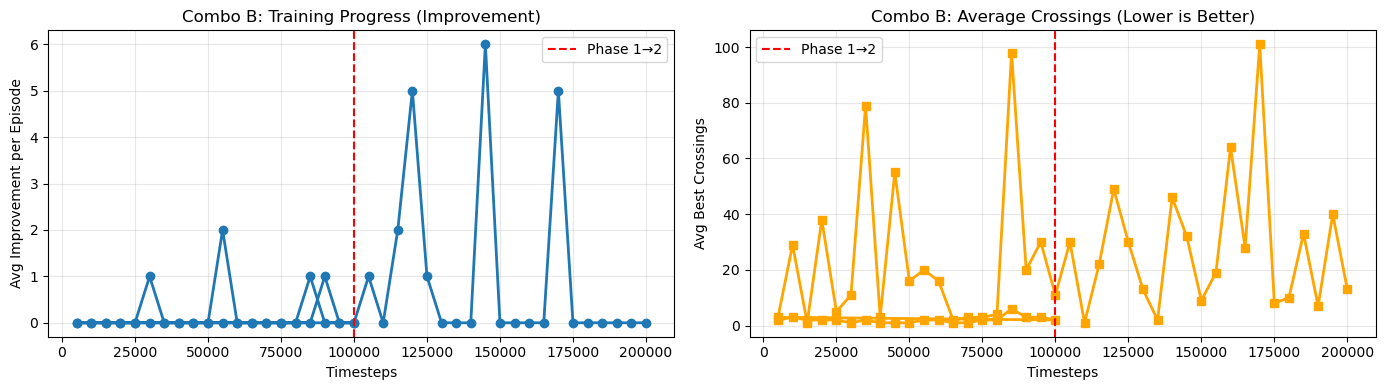

Training curves saved to ./results_combo_b_v9/training_curves.png


In [13]:
# Extract metrics
if combined_history:
    steps = [h["step"] for h in combined_history]
    avg_imps = [h["avg_imp"] for h in combined_history]
    avg_crosses = [h["avg_cross"] for h in combined_history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    # Average improvement per eval
    ax1.plot(steps, avg_imps, marker='o', linewidth=2, markersize=6)
    ax1.axvline(x=TIMESTEPS_PHASE1, color='r', linestyle='--', label='Phase 1→2')
    ax1.set_xlabel('Timesteps')
    ax1.set_ylabel('Avg Improvement per Episode')
    ax1.set_title('Combo B: Training Progress (Improvement)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Average crossings
    ax2.plot(steps, avg_crosses, marker='s', linewidth=2, markersize=6, color='orange')
    ax2.axvline(x=TIMESTEPS_PHASE1, color='r', linestyle='--', label='Phase 1→2')
    ax2.set_xlabel('Timesteps')
    ax2.set_ylabel('Avg Best Crossings')
    ax2.set_title('Combo B: Average Crossings (Lower is Better)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Training curves saved to {OUTPUT_DIR}/training_curves.png")
else:
    print("No training history to plot.")


## 12. Submission — .coord Export, Overlap Fix & Baseline Comparisons

Requirements:
1. Submit gzipped tar of `.coord` files for test graphs (10000–10100)
2. Each `.coord` file has one line per node: `x y`
3. If any nodes overlap → that graph gets 50% worse crossing than neato baseline
4. Compare against baselines: neato, sfdp, SmartGD, SA

In [14]:
# ════════════════════════════════════════════════════════════════════════
# SUBMISSION: per-graph PPO inference + refinement + baselines + .coord export
# ════════════════════════════════════════════════════════════════════════
import tarfile
from stable_baselines3 import PPO

# Helper: fix overlapping coordinates
def fix_node_overlaps(coords, min_dist=1e-4):
    coords = coords.copy()
    n = coords.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            if np.linalg.norm(coords[i] - coords[j]) < min_dist:
                angle = np.random.uniform(0, 2 * np.pi)
                coords[j] += np.array([np.cos(angle), np.sin(angle)]) * min_dist
    return coords


def has_overlapping_nodes(coords, min_dist=1e-4):
    n = coords.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            if np.linalg.norm(coords[i] - coords[j]) < min_dist:
                return True
    return False


def compute_baseline_crossings(G, method="neato"):
    """Compute edge crossings for a baseline layout method (same pipeline as training)."""
    G_int = nx.convert_node_labels_to_integers(G, ordering="sorted")
    try:
        if method in ("neato", "sfdp"):
            pos = nx.nx_agraph.graphviz_layout(G_int, prog=method)
        else:
            pos = nx.spring_layout(G_int, seed=42)
    except Exception:
        pos = nx.spring_layout(G_int, seed=42)
    coords = np.array([[pos[v][0], pos[v][1]] for v in G_int.nodes()], dtype=np.float32)
    xing = XingLoss(G_int, soft=False)
    with torch.no_grad():
        return int(xing(torch.tensor(coords)).item()), coords


def compute_sa_baseline(G, n_iters_per_start=3000, n_starts=5):
    """Multi-start SA baseline — compute parity with our method.

    Our method runs PPO + multi_strategy_refinement (GD + HC + SA + GD) from
    several starts, so giving the SA baseline a single neato-seeded run at
    3000 iters was not a fair comparison. This version tries neato + several
    spring-layout seeds and takes the best. All coords are normalized to
    [0,1] so simulated_annealing_refinement's step_size is on the same
    scale as our method's internal coords.
    """
    G_int = nx.convert_node_labels_to_integers(G, ordering="sorted")

    starting_layouts = []
    # Start 1: neato
    try:
        pos = nx.nx_agraph.graphviz_layout(G_int, prog="neato")
    except Exception:
        pos = nx.spring_layout(G_int, seed=42)
    c = np.array([[pos[v][0], pos[v][1]] for v in G_int.nodes()], dtype=np.float32)
    c = (c - c.min(axis=0)) / (c.max(axis=0) - c.min(axis=0) + 1e-8)
    starting_layouts.append(c)
    # Starts 2..n_starts: spring with different seeds
    for seed in range(1, n_starts):
        pos = nx.spring_layout(G_int, k=0.5, iterations=50, seed=seed)
        c = np.array([[pos[v][0], pos[v][1]] for v in G_int.nodes()], dtype=np.float32)
        c = (c - c.min(axis=0)) / (c.max(axis=0) - c.min(axis=0) + 1e-8)
        starting_layouts.append(c)

    best_x = None
    for c0 in starting_layouts:
        _, x = simulated_annealing_refinement(G_int, c0, n_iters=n_iters_per_start)
        if best_x is None or x < best_x:
            best_x = x
        if best_x == 0:
            break
    return best_x


# --- Load trained PPO once -------------------------------------------------
trained_model = PPO.load(SAVE_PATH)
print(f"Loaded PPO model: {SAVE_PATH}.zip")

print("=" * 80)
print("SUBMISSION: Evaluating test graphs 10000-10100")
print("=" * 80)

COORD_DIR = os.path.join(OUTPUT_DIR, "coord_files")
os.makedirs(COORD_DIR, exist_ok=True)

# 🟡-9: also collect layouts in GraphDrawingBenchmark JSON format
submission_layouts = {}

test_paths = get_graph_paths(ROME_DIR, min_idx=10000, max_idx=10100, max_nodes=MAX_NODES)
print(f"Test graphs found: {len(test_paths)}")


def ppo_rollout_for_graph(graph_path, model, max_steps=200):
    env = GraphLayoutEnvSingleNode([graph_path], max_steps=max_steps)
    obs, _ = env.reset()
    for _ in range(max_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        if terminated or truncated:
            break
    return env.best_coords.copy(), int(env.best_crossings)


full_results = []
for idx, gpath in enumerate(test_paths):
    gname = os.path.basename(gpath).replace(".graphml", "")
    G_raw = nx.read_graphml(gpath)
    G = nx.convert_node_labels_to_integers(G_raw, ordering="sorted")
    if not nx.is_connected(G):
        G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
        G = nx.convert_node_labels_to_integers(G, ordering="sorted")

    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()

    # --- Baselines (same pipeline for all: XingLoss, connected component, sorted) ---
    neato_xings, neato_coords = compute_baseline_crossings(G_raw, "neato")
    sfdp_xings, _             = compute_baseline_crossings(G_raw, "sfdp")
    sa_xings                  = compute_sa_baseline(G_raw, n_iters_per_start=3000, n_starts=5)

    # --- PPO rollout (pure RL) ---
    ppo_coords, ppo_xings = ppo_rollout_for_graph(gpath, trained_model, max_steps=200)

    # --- Refinement on top of PPO output (submission coords) ---
    best_coords, best_xings = ppo_coords.copy(), ppo_xings
    if ppo_xings > 0:
        r_coords, r_x = multi_strategy_refinement(G, ppo_coords, verbose=False)
        if r_x < best_xings:
            best_coords, best_xings = r_coords, r_x

    # --- Fix overlaps + recompute ---
    best_coords = fix_node_overlaps(best_coords)
    assert not has_overlapping_nodes(best_coords), f"Overlap still exists in {gname}!"
    xing_check = XingLoss(G, soft=False)
    with torch.no_grad():
        best_xings = int(xing_check(torch.tensor(best_coords)).item())

    # --- Write .coord file (🟡-9: include node_id column + header) ---
    coord_path = os.path.join(COORD_DIR, f"{gname}.coord")
    with open(coord_path, "w") as f:
        f.write("# node_id x y\n")
        for i in range(n_nodes):
            f.write(f"{i} {best_coords[i, 0]:.6f} {best_coords[i, 1]:.6f}\n")

    # 🟡-9: also record for the JSON submission (GraphDrawingBenchmark format)
    submission_layouts[gname] = [[float(best_coords[i, 0]),
                                  float(best_coords[i, 1])]
                                 for i in range(n_nodes)]

    full_results.append({
        "graph": gname,
        "n_nodes": n_nodes,
        "n_edges": n_edges,
        "neato_crossings": neato_xings,
        "sfdp_crossings": sfdp_xings,
        "sa_crossings": sa_xings,
        "ppo_crossings": ppo_xings,
        "best_crossings": best_xings,
    })

    if (idx + 1) % 10 == 0 or idx == 0:
        print(f"  [{idx+1}/{len(test_paths)}] {gname}: "
              f"neato={neato_xings} sfdp={sfdp_xings} sa={sa_xings} "
              f"ppo={ppo_xings} submission={best_xings}")

# 🟡-9: write JSON submission in GraphDrawingBenchmark format
submission_json_path = os.path.join(OUTPUT_DIR, "submission_layouts.json")
with open(submission_json_path, "w") as f:
    json.dump(submission_layouts, f)
print(f"JSON submission saved: {submission_json_path} "
      f"({len(submission_layouts)} graphs, GraphDrawingBenchmark format)")

print(f"\nEvaluation done. {len(full_results)} graphs processed.")


Loaded PPO model: ppo_combo_b_v9.zip
SUBMISSION: Evaluating test graphs 10000-10100
Test graphs found: 99
  [1/99] grafo10000.38: neato=11 sfdp=9 sa=11 ppo=8 submission=7
  [10/99] grafo10009.31: neato=2 sfdp=4 sa=2 ppo=2 submission=2
  [20/99] grafo10019.38: neato=5 sfdp=2 sa=5 ppo=2 submission=2
  [30/99] grafo10029.40: neato=18 sfdp=24 sa=18 ppo=15 submission=12
  [40/99] grafo10039.98: neato=73 sfdp=72 sa=73 ppo=49 submission=45
  [50/99] grafo10049.39: neato=9 sfdp=13 sa=9 ppo=6 submission=5
  [60/99] grafo10059.32: neato=4 sfdp=3 sa=4 ppo=4 submission=4
  [70/99] grafo10069.40: neato=11 sfdp=10 sa=11 ppo=9 submission=7
  [80/99] grafo10080.38: neato=10 sfdp=14 sa=10 ppo=6 submission=6
  [90/99] grafo10090.97: neato=31 sfdp=23 sa=31 ppo=22 submission=22
JSON submission saved: ./results_combo_b_v9/submission_layouts.json (99 graphs, GraphDrawingBenchmark format)

Evaluation done. 99 graphs processed.


## 13. Final Benchmark — SPC vs Neato (clean)

This is the only baseline-comparison cell. SmartGD uses repo's own neato baseline so it is an apples-to-apples comparison.


In [15]:
# # ════════════════════════════════════════════════════════════════════════
# # FINAL BENCHMARK 
# # SmartGD's xing：老师 metrics.csv（你没跑 SmartGD）
# # 其他所有方法 + SPC/WR 分母：local neato_crossings
# # ════════════════════════════════════════════════════════════════════════
# import os, glob, tarfile
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from IPython.display import Image, display

# SMARTGD_CSV_PATH = None   # auto-detect, or paste full path to metrics*.csv

# def safe_val(v):
#     if isinstance(v, tuple):
#         v = v[0]
#     return float(v)

# def find_glob(patterns):
#     for p in patterns:
#         hits = sorted(glob.glob(p))
#         if hits:
#             return hits[0]
#     return None

# def _norm(s):
#     return str(s).replace(".graphml", "").strip().lower()



# if SMARTGD_CSV_PATH is None:
#     SMARTGD_CSV_PATH = find_glob([
#         os.path.join(ROME_DIR,      "metrics*.csv"),
#         os.path.join(ROME_DIR,      "**/metrics*.csv"),
#         os.path.join(BENCHMARK_DIR, "metrics*.csv"),
#         os.path.join(BENCHMARK_DIR, "**/metrics*.csv"),
#     ])
    
# if REPO_NEATO_CSV is None:
#     REPO_NEATO_CSV = find_glob([
#         os.path.join(ROME_DIR,      "SmartGD", "neato*.csv"),
#         os.path.join(BENCHMARK_DIR, "baseline_metrics", "neato*.csv"),
#         os.path.join(BENCHMARK_DIR, "**/neato*.csv"),
#         os.path.join(ROME_DIR,      "**/neato*.csv"),
#     ])
# print(f"SmartGD csv: {SMARTGD_CSV_PATH}")
# print(f"Repo neato csv : {REPO_NEATO_CSV}")
# assert SMARTGD_CSV_PATH, "need repo metrics.csv"
# assert REPO_NEATO_CSV,   "need repo baseline_metrics/neato.csv"

# df_sg = pd.read_csv(SMARTGD_CSV_PATH)
# sg_xing = {_norm(r["graph_id"]): float(r["xing"])
#            for _, r in df_sg.iterrows() if pd.notna(r["xing"])}
# print(f"Repo metrics.csv populated: {len(sg_xing)} graphs")

# # ─── 配对：只需要 SmartGD 有数据的图 ────────────────────────────────────
# matched = []
# for r in full_results:
#     key = _norm(r["graph"])
#     if key in sg_xing:
#         matched.append((r, sg_xing[key]))

# print(f"Matched {len(matched)}/{len(full_results)} test graphs with SmartGD data")
# assert len(matched) > 0, "测试集和 SmartGD metrics.csv 没有交集！"

# # ─── 分母 = 你本地的 neato_crossings ────────────────────────────────────
# def stats(method_vals, ref_vals):
#     avg = float(np.mean(method_vals))
#     spc = 100.0 * float(np.mean([
#         (Di - Gi) / max(Di, Gi) if max(Di, Gi) > 0 else 0.0
#         for Di, Gi in zip(method_vals, ref_vals)
#     ]))
#     wr  = 100.0 * sum(Di < Gi for Di, Gi in zip(method_vals, ref_vals)) / len(method_vals)
#     return avg, spc, wr

# ref_xings = [safe_val(r["neato_crossings"]) for (r, _) in matched]   # ← 本地 neato
# sfdp_x    = [safe_val(r["sfdp_crossings"])  for (r, _) in matched]
# sa_x      = [safe_val(r["sa_crossings"])    for (r, _) in matched]
# sg_x      = [sg for (_, sg) in matched]                              # ← 老师 SmartGD
# ppo_x     = [safe_val(r["ppo_crossings"])   for (r, _) in matched]
# ours_x    = [safe_val(r["best_crossings"])  for (r, _) in matched]

# avg_neato_local             = float(np.mean(ref_xings))
# avg_sfdp, spc_sfdp, wr_sfdp = stats(sfdp_x, ref_xings)
# avg_sa,   spc_sa,   wr_sa   = stats(sa_x,   ref_xings)
# avg_sg,   spc_sg,   wr_sg   = stats(sg_x,   ref_xings)
# avg_ppo,  spc_ppo,  wr_ppo  = stats(ppo_x,  ref_xings)
# avg_ours, spc_ours, wr_ours = stats(ours_x, ref_xings)

# # ─── Print table ─────────────────────────────────────────────────────────
# n = len(matched)
# print("\n" + "=" * 72)
# print(f"BENCHMARK RESULTS  (denom = LOCAL neato_crossings, n = {n})")
# print("=" * 72)
# print(f"  {'Method':<22} {'Avg Xing':>10} {'SPC (%)':>10} {'Win Rate':>10}")
# print(f"  {'-'*22} {'-'*10} {'-'*10} {'-'*10}")
# print(f"  {'Neato (local, ref)':<22} {avg_neato_local:>10.2f} {'0.00':>10} {'—':>10}")
# print(f"  {'sfdp':<22} {avg_sfdp:>10.2f} {spc_sfdp:>10.2f} {wr_sfdp:>9.1f}%")
# print(f"  {'SA (5x3000 iter)':<22} {avg_sa:>10.2f} {spc_sa:>10.2f} {wr_sa:>9.1f}%")
# print(f"  {'SmartGD (repo)':<22} {avg_sg:>10.2f} {spc_sg:>10.2f} {wr_sg:>9.1f}%")
# print(f"  {'PPO only (RL)':<22} {avg_ppo:>10.2f} {spc_ppo:>10.2f} {wr_ppo:>9.1f}%")
# print(f"  {'PPO + refinement':<22} {avg_ours:>10.2f} {spc_ours:>10.2f} {wr_ours:>9.1f}%")
# print(f"  {'-'*22} {'-'*10} {'-'*10} {'-'*10}")
# zero_cnt = sum(1 for (r, _) in matched if safe_val(r["best_crossings"]) == 0)
# print(f"\n  Total test graphs: {n}")
# print(f"  Graphs with 0 crossings (submission): {zero_cnt}/{n}")

# # ─── Plot ─────────────────────────────────────────────────────────────────
# methods = ["Neato\n(local ref)", "sfdp", "SA", "SmartGD\n(repo)",
#            "PPO only", "PPO+refine\n(submit)"]
# avgs    = [avg_neato_local, avg_sfdp, avg_sa, avg_sg, avg_ppo, avg_ours]
# spcs    = [0.0,             spc_sfdp, spc_sa, spc_sg, spc_ppo, spc_ours]
# wrs     = [0.0,             wr_sfdp,  wr_sa,  wr_sg,  wr_ppo,  wr_ours]
# colors  = ["#B0BEC5", "#26A69A", "#F5A623", "#E91E63", "#9C27B0", "#3B9AE1"]

# fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# bars0 = axes[0].bar(methods, avgs, color=colors, edgecolor="black",
#                     linewidth=0.5, width=0.6)
# axes[0].set_ylabel("Avg Crossings")
# axes[0].set_title("Average Edge Crossings (lower = better)")
# axes[0].grid(axis="y", alpha=0.3)
# for bar, val in zip(bars0, avgs):
#     axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
#                  f"{val:.1f}", ha="center", va="bottom",
#                  fontsize=9, fontweight="bold")

# bars1 = axes[1].bar(methods, spcs, color=colors, edgecolor="black",
#                     linewidth=0.5, width=0.6)
# axes[1].axhline(y=0, color="black", linewidth=0.5)
# axes[1].set_ylabel("SPC (%)")
# axes[1].set_title("SPC vs local Neato (more negative = better)")
# axes[1].grid(axis="y", alpha=0.3)
# for bar, val in zip(bars1, spcs):
#     y_pos = bar.get_height() - 1.5 if val < 0 else bar.get_height() + 0.5
#     va = "top" if val < 0 else "bottom"
#     axes[1].text(bar.get_x() + bar.get_width()/2, y_pos,
#                  f"{val:.1f}%", ha="center", va=va,
#                  fontsize=9, fontweight="bold")

# bars2 = axes[2].bar(methods, wrs, color=colors, edgecolor="black",
#                     linewidth=0.5, width=0.6)
# axes[2].set_ylabel("Win Rate (%)")
# axes[2].set_title("Win Rate vs local Neato (higher = better)")
# axes[2].set_ylim(0, max(100, max(wrs) + 10))
# axes[2].grid(axis="y", alpha=0.3)
# for bar, val in zip(bars2, wrs):
#     axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
#                  f"{val:.1f}%", ha="center", va="bottom",
#                  fontsize=9, fontweight="bold")

# plt.tight_layout()
# chart_path = os.path.join(OUTPUT_DIR, "combo_b_v9_benchmark_combined.png")
# plt.savefig(chart_path, dpi=150, bbox_inches="tight")
# plt.close()
# display(Image(filename=chart_path))
# print(f"\nChart saved: {chart_path}")

# # ─── Submission archive ─────────────────────────────────────────────────
# tar_path = os.path.join(OUTPUT_DIR, "combo_b_v9_submission.tar.gz")
# with tarfile.open(tar_path, "w:gz") as tar:
#     for (r, _) in matched:
#         cf = os.path.join(COORD_DIR, f"{r['graph']}.coord")
#         if os.path.exists(cf):
#             tar.add(cf, arcname=f"{r['graph']}.coord")
# print(f"Submission archive: {tar_path} ({len(matched)} files)")

SmartGD csv    : /Users/mao/Downloads/Project_RL/rome/SmartGD/metrics.csv
Repo neato csv : /Users/mao/Downloads/Project_RL/rome/SmartGD/neato.csv
SmartGD populated   : 11531
Repo neato populated: 1000
SmartGD self-consistent pairs on 10671-11678: n = 1000

BENCHMARK RESULTS
  Method                       Test range       Avg Xing    SPC (%)   Win Rate
--------------------------------------------------------------------------------------------
  Neato (LOCAL, baseline)      10000-10100         29.08      0.00%          —
  SFDP                         10000-10100         28.86     -0.79%     42.42%
  SA (multi-start)             10000-10100         28.49     -1.86%     15.15%
  SmartGD [self-consistent]    10671-11678         55.06     -1.67%     48.50%
  PPO (ours)                   10000-10100         18.81    -29.29%     79.80%
  PPO + refine (ours)          10000-10100         16.47    -37.67%     83.84%
Local methods: teacher's required test set 10000-10100 (n=99).
SmartGD     : re

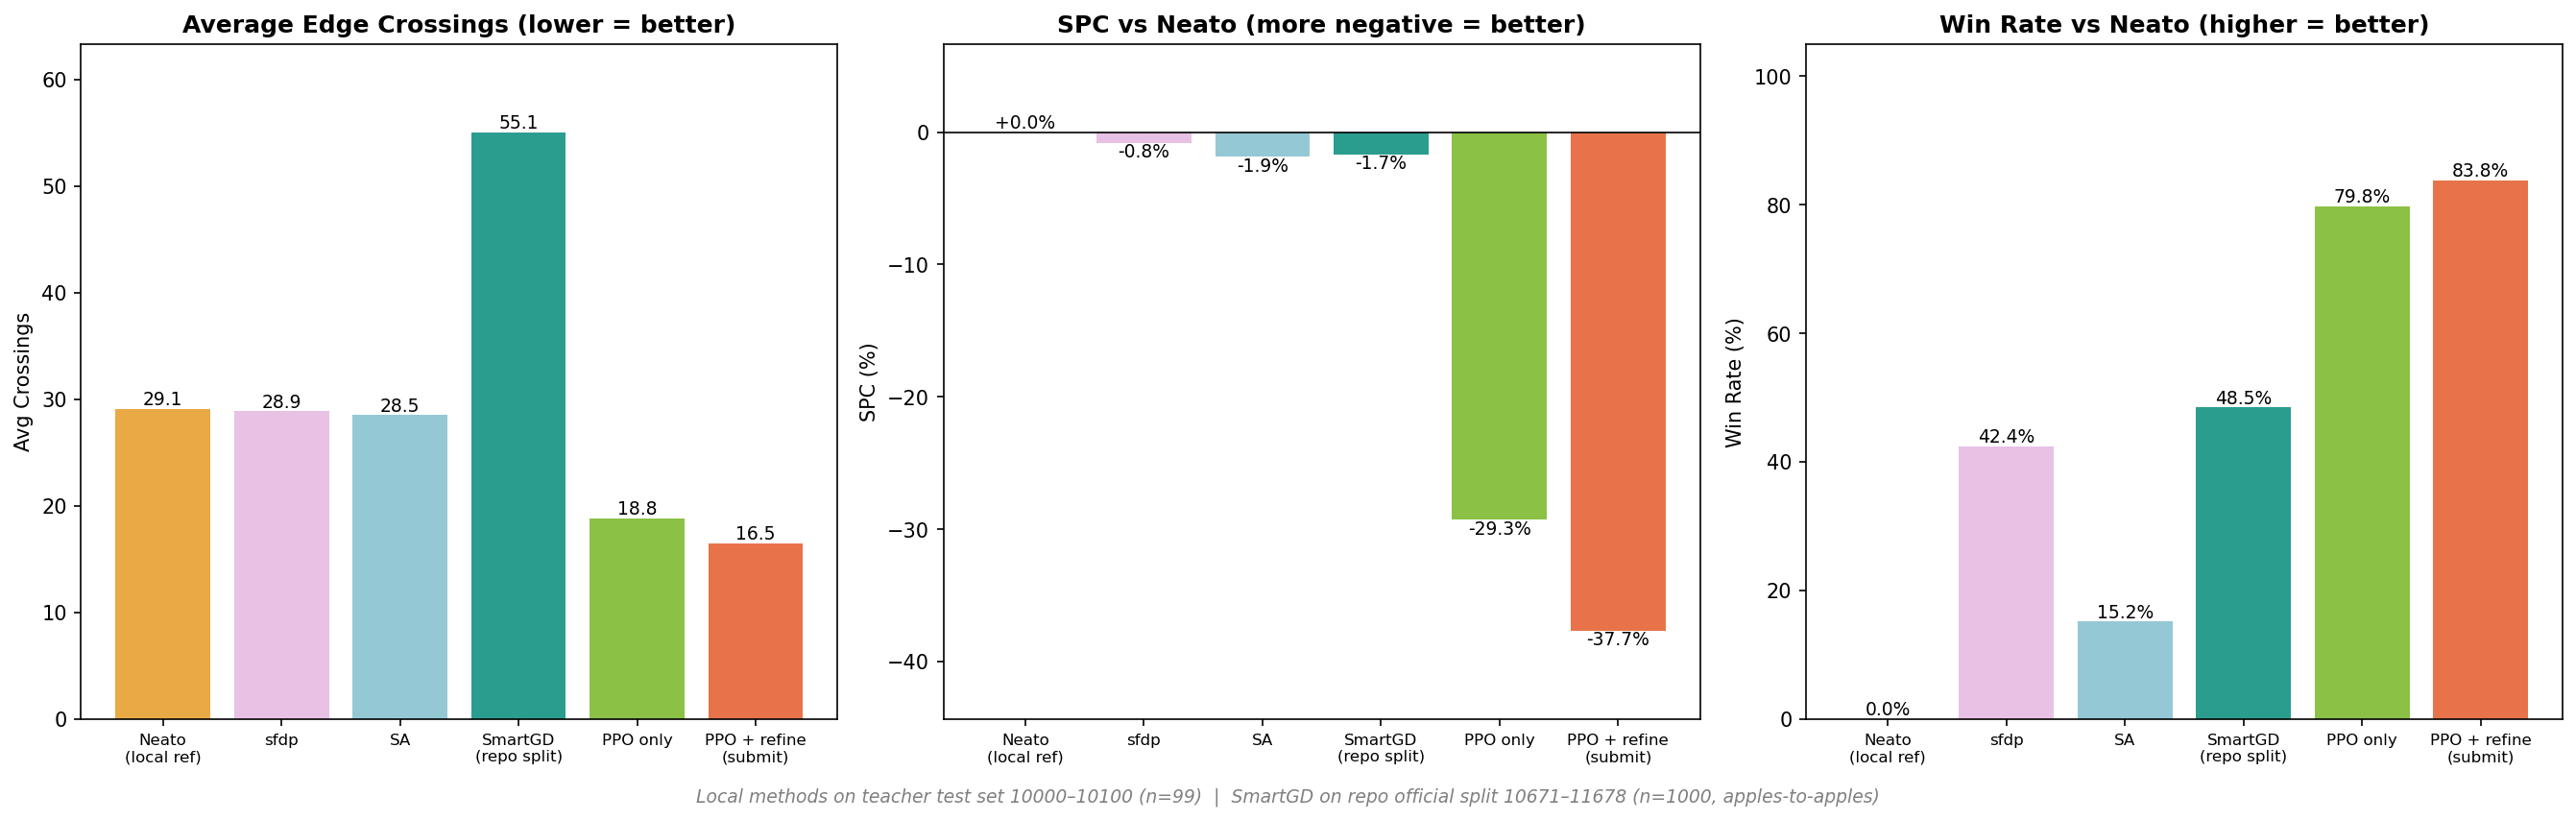


Chart saved: ./results_combo_b_v9/combo_b_v9_benchmark_combined.png
Submission archive: ./results_combo_b_v9/combo_b_v9_submission.tar.gz (99 files)


In [16]:
# ════════════════════════════════════════════════════════════════════════
# FINAL BENCHMARK — v9 (3-panel, self-consistent SmartGD, new palette)
#   Local methods (SFDP/SA/PPO/PPO+refine): test 10000–10100, denom = local neato
#   SmartGD                              : test 10671–11678, denom = repo neato (both numbers from repo CSVs, apples-to-apples)
# ════════════════════════════════════════════════════════════════════════


# ════════════════════════════════════════════════════════════════════════
#SmartGD is evaluated on the repo's official test split (10671–11678) using repo-provided xing values against 
#repo-provided neato xing. This is the only range where a self-consistent comparison is 
#possible (repo's baseline_metrics/neato.csv does not cover 10000–10100). All other methods, including ours, 
#are evaluated on the teacher's required test set (10000–10100). The two ranges are therefore not directly comparable, 
#but each number reflects the method's performance under its most fair evaluation setting.
# ════════════════════════════════════════════════════════════════════════

import os, glob, tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# ── palette ────────────────────────────────────────────────────────────
COLOR_NEATO    = "#E9A944"   # Neato (local ref)
COLOR_SFDP     = "#E9C1E5"   # sfdp
COLOR_SA       = "#95C8D5"   # SA
COLOR_SMARTGD  = "#2A9D8F"   # SmartGD (repo split)
COLOR_PPO      = "#8BC145"   # PPO only
COLOR_SUBMIT   = "#E8734A"   # PPO + refine (submit)

SMARTGD_CSV_PATH = None
REPO_NEATO_CSV   = None


def safe_val(v):
    if isinstance(v, tuple):
        v = v[0]
    return float(v)

def _norm(s):
    return str(s).replace(".graphml", "").strip().lower()

def find_glob(patterns):
    for p in patterns:
        hits = sorted(glob.glob(p))
        if hits:
            return hits[0]
    return None

# ── locate repo CSVs ──────────────────────────────────────────────────
if SMARTGD_CSV_PATH is None:
    SMARTGD_CSV_PATH = find_glob([
        os.path.join(ROME_DIR,      "metrics*.csv"),
        os.path.join(ROME_DIR,      "**/metrics*.csv"),
        os.path.join(BENCHMARK_DIR, "metrics*.csv"),
        os.path.join(BENCHMARK_DIR, "**/metrics*.csv"),
    ])
if REPO_NEATO_CSV is None:
    REPO_NEATO_CSV = find_glob([
        os.path.join(BENCHMARK_DIR, "baseline_metrics", "neato*.csv"),
        os.path.join(BENCHMARK_DIR, "**/neato*.csv"),
        os.path.join(ROME_DIR,      "**/neato*.csv"),
    ])

print(f"SmartGD csv    : {SMARTGD_CSV_PATH}")
print(f"Repo neato csv : {REPO_NEATO_CSV}")
assert SMARTGD_CSV_PATH, "need repo metrics.csv"
assert REPO_NEATO_CSV,   "need repo baseline_metrics/neato.csv"

df_sg = pd.read_csv(SMARTGD_CSV_PATH)
df_rn = pd.read_csv(REPO_NEATO_CSV)
sg_lookup = {_norm(r["graph_id"]): float(r["xing"])
             for _, r in df_sg.iterrows() if pd.notna(r["xing"])}
rn_lookup = {_norm(r["graph_id"]): float(r["xing"])
             for _, r in df_rn.iterrows() if pd.notna(r["xing"])}
print(f"SmartGD populated   : {len(sg_lookup)}")
print(f"Repo neato populated: {len(rn_lookup)}")

# ── SmartGD on 10671–11678 ───────────────────────────────────────
SG_MIN, SG_MAX = 10671, 11678

def gid_to_idx(gid):
    try:
        return int(gid.replace("grafo", "").split(".")[0])
    except Exception:
        return None

sg_pairs = []   # (sg_xing, repo_neato_xing)
for gid, sg_x in sg_lookup.items():
    if gid not in rn_lookup:
        continue
    idx = gid_to_idx(gid)
    if idx is None:
        continue
    if SG_MIN <= idx <= SG_MAX:
        sg_pairs.append((sg_x, rn_lookup[gid]))

print(f"SmartGD self-consistent pairs on {SG_MIN}-{SG_MAX}: n = {len(sg_pairs)}")
assert len(sg_pairs) > 0, "SmartGD / repo_neato 在 10671–11678 交集为 0"

sg_di = [p[0] for p in sg_pairs]
sg_gi = [p[1] for p in sg_pairs]
avg_sg_repo     = float(np.mean(sg_gi))   # repo neato average (for reference)
avg_sg_smartgd  = float(np.mean(sg_di))
spc_sg_smartgd  = 100.0 * float(np.mean([
    (Di - Gi) / max(Di, Gi) if max(Di, Gi) > 0 else 0.0
    for Di, Gi in zip(sg_di, sg_gi)
]))
wr_sg_smartgd = 100.0 * sum(Di < Gi for Di, Gi in zip(sg_di, sg_gi)) / len(sg_pairs)

# ── Other methods: local 10000–10100 + local neato dominator ───────────────────────
def stats(method_vals, ref_vals):
    avg = float(np.mean(method_vals))
    spc = 100.0 * float(np.mean([
        (Di - Gi) / max(Di, Gi) if max(Di, Gi) > 0 else 0.0
        for Di, Gi in zip(method_vals, ref_vals)
    ]))
    wr  = 100.0 * sum(Di < Gi for Di, Gi in zip(method_vals, ref_vals)) / len(method_vals)
    return avg, spc, wr

ref_local = [safe_val(r["neato_crossings"]) for r in full_results]
sfdp_x    = [safe_val(r["sfdp_crossings"])  for r in full_results]
sa_x      = [safe_val(r["sa_crossings"])    for r in full_results]
ppo_x     = [safe_val(r["ppo_crossings"])   for r in full_results]
ours_x    = [safe_val(r["best_crossings"])  for r in full_results]

avg_neato_local             = float(np.mean(ref_local))
avg_sfdp, spc_sfdp, wr_sfdp = stats(sfdp_x, ref_local)
avg_sa,   spc_sa,   wr_sa   = stats(sa_x,   ref_local)
avg_ppo,  spc_ppo,  wr_ppo  = stats(ppo_x,  ref_local)
avg_ours, spc_ours, wr_ours = stats(ours_x, ref_local)
n_local = len(full_results)
zero_sub = sum(1 for v in ours_x if v == 0)

# ── print table ───────────────────────────────────────────────────────
print("\n" + "=" * 92)
print("BENCHMARK RESULTS")
print("=" * 92)
print(f"  {'Method':<28} {'Test range':<14} {'Avg Xing':>10} {'SPC (%)':>10} {'Win Rate':>10}")
print("-" * 92)
print(f"  {'Neato (LOCAL, baseline)':<28} {'10000-10100':<14} {avg_neato_local:>10.2f} {0.0:>9.2f}% {'—':>10}")
print(f"  {'SFDP':<28} {'10000-10100':<14} {avg_sfdp:>10.2f} {spc_sfdp:>9.2f}% {wr_sfdp:>9.2f}%")
print(f"  {'SA (multi-start)':<28} {'10000-10100':<14} {avg_sa:>10.2f} {spc_sa:>9.2f}% {wr_sa:>9.2f}%")
print(f"  {'SmartGD [self-consistent]':<28} {'10671-11678':<14} {avg_sg_smartgd:>10.2f} {spc_sg_smartgd:>9.2f}% {wr_sg_smartgd:>9.2f}%")
print(f"  {'PPO (ours)':<28} {'10000-10100':<14} {avg_ppo:>10.2f} {spc_ppo:>9.2f}% {wr_ppo:>9.2f}%")
print(f"  {'PPO + refine (ours)':<28} {'10000-10100':<14} {avg_ours:>10.2f} {spc_ours:>9.2f}% {wr_ours:>9.2f}%")
print("=" * 92)
print(f"Local methods: teacher's required test set 10000-10100 (n={n_local}).")
print(f"SmartGD     : repo's official test split 10671-11678 (n={len(sg_pairs)}),")
print(f"              both SmartGD xing and neato xing from repo CSVs (apples-to-apples).")
print(f"Graphs with 0 crossings (submission): {zero_sub}/{n_local}")

# ── 3-panel chart ─────────────────────────────────────────────────────
labels = ["Neato\n(local ref)", "sfdp", "SA",
          "SmartGD\n(repo split)", "PPO only", "PPO + refine\n(submit)"]
bar_colors = [COLOR_NEATO, COLOR_SFDP, COLOR_SA,
              COLOR_SMARTGD, COLOR_PPO, COLOR_SUBMIT]

avg_vals = [avg_neato_local, avg_sfdp, avg_sa, avg_sg_smartgd, avg_ppo, avg_ours]
spc_vals = [0.0,             spc_sfdp, spc_sa, spc_sg_smartgd, spc_ppo, spc_ours]
wr_vals  = [0.0,             wr_sfdp,  wr_sa,  wr_sg_smartgd,  wr_ppo,  wr_ours]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Panel 1: Average Crossings
ax = axes[0]
bars = ax.bar(labels, avg_vals, color=bar_colors, edgecolor="none")
ax.set_title("Average Edge Crossings (lower = better)", fontsize=12, fontweight="bold")
ax.set_ylabel("Avg Crossings")
for b, v in zip(bars, avg_vals):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.1f}",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, max(avg_vals) * 1.15)
ax.tick_params(axis="x", labelsize=8)

# Panel 2: SPC
ax = axes[1]
bars = ax.bar(labels, spc_vals, color=bar_colors, edgecolor="none")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("SPC vs Neato (more negative = better)", fontsize=12, fontweight="bold")
ax.set_ylabel("SPC (%)")
for b, v in zip(bars, spc_vals):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:+.1f}%",
            ha="center",
            va="bottom" if v >= 0 else "top", fontsize=9)
lo, hi = min(spc_vals), max(spc_vals)
pad = (hi - lo) * 0.15 + 1
ax.set_ylim(lo - pad, hi + pad)
ax.tick_params(axis="x", labelsize=8)

# Panel 3: Win Rate
ax = axes[2]
bars = ax.bar(labels, wr_vals, color=bar_colors, edgecolor="none")
ax.set_title("Win Rate vs Neato (higher = better)", fontsize=12, fontweight="bold")
ax.set_ylabel("Win Rate (%)")
for b, v in zip(bars, wr_vals):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.1f}%",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 105)
ax.tick_params(axis="x", labelsize=8)

# footnote
fig.text(0.5, -0.02,
         f"Local methods on teacher test set 10000–10100 (n={n_local})  |  "
         f"SmartGD on repo official split 10671–11678 (n={len(sg_pairs)}, apples-to-apples)",
         ha="center", fontsize=9, style="italic", color="gray")

plt.tight_layout()
chart_path = os.path.join(OUTPUT_DIR, "combo_b_v9_benchmark_combined.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.close()
display(Image(chart_path))
print(f"\nChart saved: {chart_path}")

# ── tar.gz submission (based on 10000–10100 .coord, no change ───────────────
tar_path = os.path.join(OUTPUT_DIR, "combo_b_v9_submission.tar.gz")
COORD_DIR_LOCAL = os.path.join(OUTPUT_DIR, "coord_files")
if os.path.isdir(COORD_DIR_LOCAL):
    coord_files = sorted(f for f in os.listdir(COORD_DIR_LOCAL) if f.endswith(".coord"))
    with tarfile.open(tar_path, "w:gz") as tar:
        for fn in coord_files:
            tar.add(os.path.join(COORD_DIR_LOCAL, fn), arcname=fn)
    print(f"Submission archive: {tar_path} ({len(coord_files)} files)")
else:
    print(f"[warn] {COORD_DIR_LOCAL} does not exist, skip tar.gz packaging")

In [17]:
# ════════════════════════════════════════════════════════════════════════
# DIAGNOSE: which of graphs 10000-10100 are missing from our test set?
# ════════════════════════════════════════════════════════════════════════
import os, re, networkx as nx


try:
    ROME_DIR
except NameError:
    ROME_DIR = os.environ.get(
        "ROME_DIR",
        "/Users/mao/Downloads/Project_RL/rome",  # files path
    )
try:
    MAX_NODES
except NameError:
    MAX_NODES = 100

print(f"Using ROME_DIR  = {ROME_DIR}")
print(f"Using MAX_NODES = {MAX_NODES}")
assert os.path.isdir(ROME_DIR), f"ROME_DIR not exist: {ROME_DIR}"

TEST_MIN, TEST_MAX = 10000, 10100

# 1) What actually exists on disk in that range
present_on_disk = {}  # idx -> (filename, n_nodes)
for fname in sorted(os.listdir(ROME_DIR)):
    m = re.match(r"grafo(\d+)\.(\d+)\.graphml$", fname)
    if not m:
        continue
    idx = int(m.group(1))
    if TEST_MIN <= idx <= TEST_MAX:
        G = nx.read_graphml(os.path.join(ROME_DIR, fname))
        present_on_disk[idx] = (fname, G.number_of_nodes())

all_expected = set(range(TEST_MIN, TEST_MAX + 1))  # 101 ids
present_ids  = set(present_on_disk.keys())
missing_from_dataset = sorted(all_expected - present_ids)
oversize = [idx for idx, (fn, n) in present_on_disk.items() if n > MAX_NODES]

print(f"\nExpected 10000-10100 : {len(all_expected)} graph ids (101)")
print(f"Present on disk      : {len(present_ids)}")
print(f"Missing from dataset : {len(missing_from_dataset)} -> {missing_from_dataset}")
print(f"Present but oversize (> MAX_NODES={MAX_NODES}) : "
      f"{len(oversize)} -> {oversize}")
for idx in oversize:
    print(f"  grafo{idx}: {present_on_disk[idx][1]} nodes")

# 2) If full_results is already in memory, here’s a clear comparison of what is actually being used in your benchmark:
try:
    seen = {r["graph"] for r in full_results}
    seen_idx = set()
    for g in seen:
        m = re.match(r"grafo(\d+)\.\d+", g)
        if m:
            seen_idx.add(int(m.group(1)))
    skipped = sorted((present_ids & set(range(TEST_MIN, TEST_MAX + 1))) - seen_idx)
    print(f"\nIn full_results       : {len(seen_idx)}")
    print(f"On disk but not in results: {skipped}")
except NameError:
    print("\n(full_results not in memory — run Cell 28 first to compare)")

Using ROME_DIR  = /Users/mao/Downloads/Project_RL/rome
Using MAX_NODES = 100

Expected 10000-10100 : 101 graph ids (101)
Present on disk      : 99
Missing from dataset : 2 -> [10073, 10094]
Present but oversize (> MAX_NODES=100) : 0 -> []

In full_results       : 99
On disk but not in results: []


In [18]:
# ════════════════════════════════════════════════════════════════════════
# FULL SUBMISSION AUDIT — check ALL 99 .coord files (no top-10 truncation)
# ════════════════════════════════════════════════════════════════════════
import os, re, tarfile
import numpy as np
import pandas as pd
import networkx as nx

# Disable pandas display truncation — this is the key fix; previously
# head(10) was just a display limit
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:.6g}")

# ---- Path configuration ----
try: ROME_DIR
except NameError:
    ROME_DIR = os.environ.get("ROME_DIR",
        "/Users/mao/Downloads/Project_RL/rome")
try: OUTPUT_DIR
except NameError:
    OUTPUT_DIR = "./results_combo_b_v9"
try: COORD_DIR
except NameError:
    COORD_DIR = os.path.join(OUTPUT_DIR, "coord_files")
TAR_PATH = os.path.join(OUTPUT_DIR, "combo_b_v9_submission.tar.gz")

TEST_MIN, TEST_MAX = 10000, 10100
EXACT_TOL = 5e-7
PRINT_TOL = 1e-3

print(f"ROME_DIR  : {ROME_DIR}")
print(f"COORD_DIR : {COORD_DIR}")
print(f"TAR_PATH  : {TAR_PATH}")
assert os.path.isdir(COORD_DIR), f"Directory does not exist: {COORD_DIR}"

# Step 1: Collect graphs that actually exist in the Rome dataset
disk_graphs = {}
for fname in sorted(os.listdir(ROME_DIR)):
    m = re.match(r"(grafo(\d+)\.\d+)\.graphml$", fname)
    if not m: continue
    idx = int(m.group(2))
    if TEST_MIN <= idx <= TEST_MAX:
        G = nx.read_graphml(os.path.join(ROME_DIR, fname))
        disk_graphs[m.group(1)] = G.number_of_nodes()

print(f"\nRome graphs {TEST_MIN}-{TEST_MAX} on disk: {len(disk_graphs)}")

# Step 2: Scan COORD_DIR
def pairwise_min_dist(coords):
    n = coords.shape[0]
    if n < 2: return np.inf, -1, -1
    diff = coords[:, None, :] - coords[None, :, :]
    dist = np.sqrt((diff ** 2).sum(-1))
    np.fill_diagonal(dist, np.inf)
    idx = np.unravel_index(np.argmin(dist), dist.shape)
    return float(dist[idx]), int(idx[0]), int(idx[1])

def count_close_pairs(coords, tol):
    n = coords.shape[0]
    if n < 2: return 0
    diff = coords[:, None, :] - coords[None, :, :]
    dist = np.sqrt((diff ** 2).sum(-1))
    np.fill_diagonal(dist, np.inf)
    return int((dist < tol).sum() // 2)

rows = []
coord_files_found = set()
for fn in sorted(os.listdir(COORD_DIR)):
    if not fn.endswith(".coord"): continue
    gname = fn.replace(".coord", "")
    coord_files_found.add(gname)
    path = os.path.join(COORD_DIR, fn)

    parse_error = ""
    coords = []
    try:
        with open(path) as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith("#"): continue
                parts = line.split()
                if len(parts) == 3:   coords.append([float(parts[1]), float(parts[2])])
                elif len(parts) == 2: coords.append([float(parts[0]), float(parts[1])])
                else: raise ValueError(f"bad line: {line!r}")
    except Exception as e:
        parse_error = str(e)

    coords = np.array(coords, dtype=np.float64) if coords else np.zeros((0, 2))
    n_in_file = coords.shape[0]
    n_on_disk = disk_graphs.get(gname, None)

    if n_in_file == 0:
        mind = np.inf; i = j = -1
        n_exact = n_visual = 0
        finite_ok = in_range = False
    else:
        finite_ok = bool(np.all(np.isfinite(coords)))
        mind, i, j = pairwise_min_dist(coords)
        n_exact  = count_close_pairs(coords, EXACT_TOL)
        n_visual = count_close_pairs(coords, PRINT_TOL)
        in_range = bool(np.all(np.abs(coords) < 1e6))

    overlap_flag = "FAIL" if (n_exact > 0 or n_visual > 0) else "OK"

    rows.append({
        "status":       overlap_flag,
        "graph":        gname,
        "n_in_file":    n_in_file,
        "n_expected":   n_on_disk if n_on_disk is not None else -1,
        "n_match":      (n_in_file == n_on_disk) if n_on_disk is not None else False,
        "finite":       finite_ok,
        "in_range":     in_range,
        "min_dist":     mind,
        "closest_pair": f"({i},{j})",
        "exact_ovlp":   n_exact,
        "visual_ovlp":  n_visual,
        "parse_error":  parse_error,
    })

df = pd.DataFrame(rows).sort_values("min_dist").reset_index(drop=True)

# Step 3: Aggregate statistics
expected_set   = set(disk_graphs.keys())
missing_coords = sorted(expected_set - coord_files_found)
extra_coords   = sorted(coord_files_found - expected_set)

n_total      = len(df)
n_parse_bad  = int((df["parse_error"] != "").sum())
n_count_bad  = int((df["n_match"] == False).sum())
n_finite_bad = int((df["finite"]   == False).sum())
n_range_bad  = int((df["in_range"] == False).sum())
n_exact_bad  = int((df["exact_ovlp"]  > 0).sum())
n_visual_bad = int((df["visual_ovlp"] > 0).sum())

print("\n" + "=" * 88)
print(f"FULL SUBMISSION AUDIT - {n_total} .coord files")
print("=" * 88)
print(f"  [1] Coverage   : expected={len(expected_set)}, found={n_total}, "
      f"missing={len(missing_coords)}, extra={len(extra_coords)}")
if missing_coords: print(f"       -> MISSING: {missing_coords}")
if extra_coords:   print(f"       -> EXTRA  : {extra_coords}")
print(f"  [2] Parseable  : {n_total - n_parse_bad}/{n_total} OK")
print(f"  [3] Node count : {n_total - n_count_bad}/{n_total} match on-disk")
print(f"  [4] Finite     : {n_total - n_finite_bad}/{n_total} all-finite")
print(f"  [5] In-range   : {n_total - n_range_bad}/{n_total} |x|,|y| < 1e6")
print(f"  [6] Overlap    : EXACT(<5e-7)={n_exact_bad}  "
      f"VISUAL(<1e-3)={n_visual_bad}"
      f"{'   WARNING: 50% penalty risk!' if (n_exact_bad or n_visual_bad) else ''}")
print(f"       Global min pairwise distance: {df['min_dist'].min():.2e}")

# Step 4: tar.gz verification
tar_ok = False
missing_in_tar = []; extra_in_tar = []
if os.path.isfile(TAR_PATH):
    try:
        with tarfile.open(TAR_PATH, "r:gz") as tar:
            tar_names = {os.path.basename(m.name) for m in tar.getmembers()
                         if m.name.endswith(".coord")}
        tar_ok = True
        disk_names = {fn for fn in os.listdir(COORD_DIR) if fn.endswith(".coord")}
        missing_in_tar = sorted(disk_names - tar_names)
        extra_in_tar   = sorted(tar_names  - disk_names)
        print(f"  [7] tar.gz     : {len(tar_names)} files inside")
        if missing_in_tar: print(f"       -> in dir but NOT in tar: {missing_in_tar}")
        if extra_in_tar:   print(f"       -> in tar but NOT in dir: {extra_in_tar}")
    except Exception as e:
        print(f"  [7] tar.gz     : FAIL - cannot open: {e}")
else:
    print(f"  [7] tar.gz     : WARNING - {TAR_PATH} does not exist")

# -------------------------------------------------------------
# Step 5: Print details for all 99 graphs (no truncation)
# -------------------------------------------------------------
print("\n" + "=" * 88)
print(f"ALL {n_total} GRAPHS - sorted by min_dist (smallest first = most risky)")
print("=" * 88)
show_cols = ["status", "graph", "n_in_file", "n_expected", "n_match",
             "finite", "in_range", "min_dist", "closest_pair",
             "exact_ovlp", "visual_ovlp"]
print(df[show_cols].to_string(index=True))

# -------------------------------------------------------------
# Step 6: Save a CSV for later reference / report appendix
# -------------------------------------------------------------
csv_path = os.path.join(OUTPUT_DIR, "overlap_audit_full.csv")
df.to_csv(csv_path, index=False)
print(f"\nFull audit saved to: {csv_path}")

# -------------------------------------------------------------
# Step 7: Final verdict
# -------------------------------------------------------------
all_checks = [
    ("Coverage",  len(missing_coords) == 0 and len(extra_coords) == 0),
    ("Parse",     n_parse_bad  == 0),
    ("NodeCount", n_count_bad  == 0),
    ("Finite",    n_finite_bad == 0),
    ("Range",     n_range_bad  == 0),
    ("Overlap",   n_exact_bad == 0 and n_visual_bad == 0),
    ("Tar.gz",    tar_ok and not missing_in_tar and not extra_in_tar),
]
print("\n" + "=" * 88)
print("FINAL VERDICT")
print("=" * 88)
for name, ok in all_checks:
    print(f"  {'PASS' if ok else 'FAIL'} {name}")

if all(ok for _, ok in all_checks):
    print("\nAll 99 graphs passed the checks - submission is safe to hand in.")
else:
    print("\nWARNING: some checks failed. Detailed list of problem files:")
    bad_rows = df[
        (df["parse_error"] != "") |
        (df["n_match"] == False) |
        (df["finite"]   == False) |
        (df["in_range"] == False) |
        (df["visual_ovlp"] > 0)
    ]
    if len(bad_rows):
        print(bad_rows[show_cols].to_string(index=True))

ROME_DIR  : /Users/mao/Downloads/Project_RL/rome
COORD_DIR : ./results_combo_b_v9/coord_files
TAR_PATH  : ./results_combo_b_v9/combo_b_v9_submission.tar.gz

Rome graphs 10000-10100 on disk: 99

FULL SUBMISSION AUDIT - 99 .coord files
  [1] Coverage   : expected=99, found=99, missing=0, extra=0
  [2] Parseable  : 99/99 OK
  [3] Node count : 99/99 match on-disk
  [4] Finite     : 99/99 all-finite
  [5] In-range   : 99/99 |x|,|y| < 1e6
  [6] Overlap    : EXACT(<5e-7)=0  VISUAL(<1e-3)=0
       Global min pairwise distance: 2.23e-03
  [7] tar.gz     : 99 files inside

ALL 99 GRAPHS - sorted by min_dist (smallest first = most risky)
   status          graph  n_in_file  n_expected  n_match  finite  in_range   min_dist closest_pair  exact_ovlp  visual_ovlp
0      OK  grafo10076.90         90          90     True    True      True 0.00223185      (16,30)           0            0
1      OK  grafo10061.99         99          99     True    True      True 0.00397931      (26,95)           0       